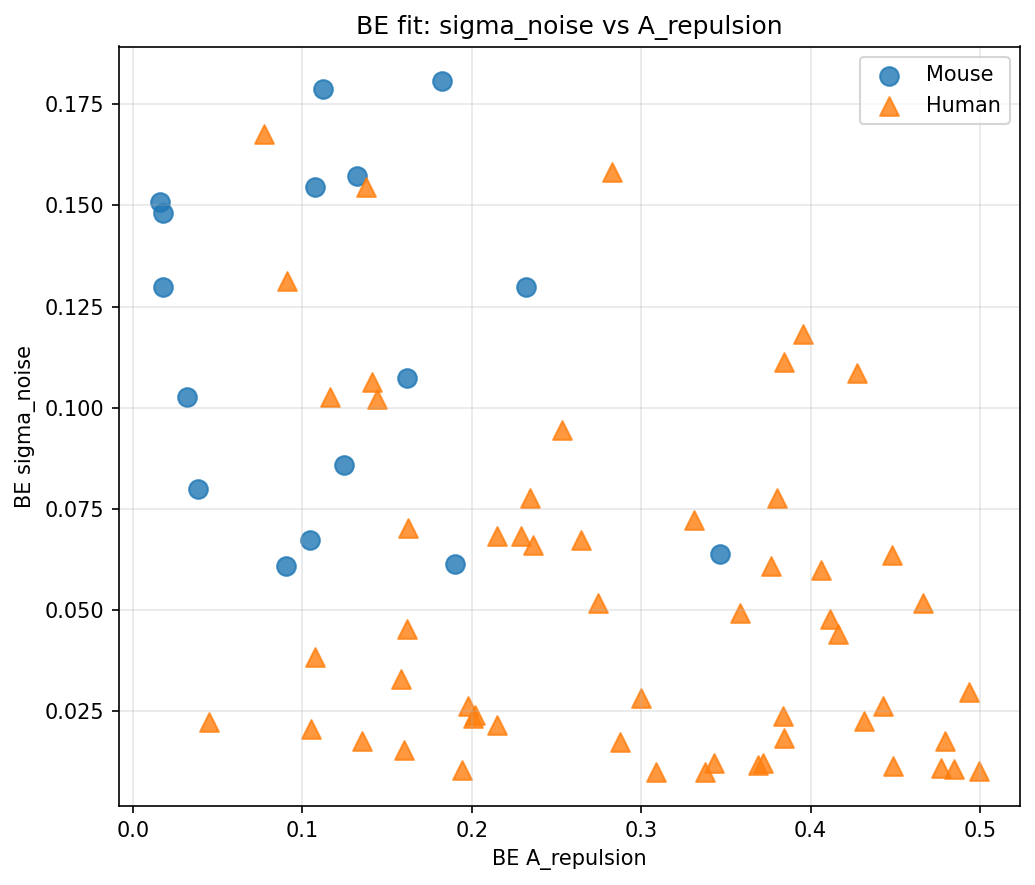

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\BE_noise_vs_repulsion.png


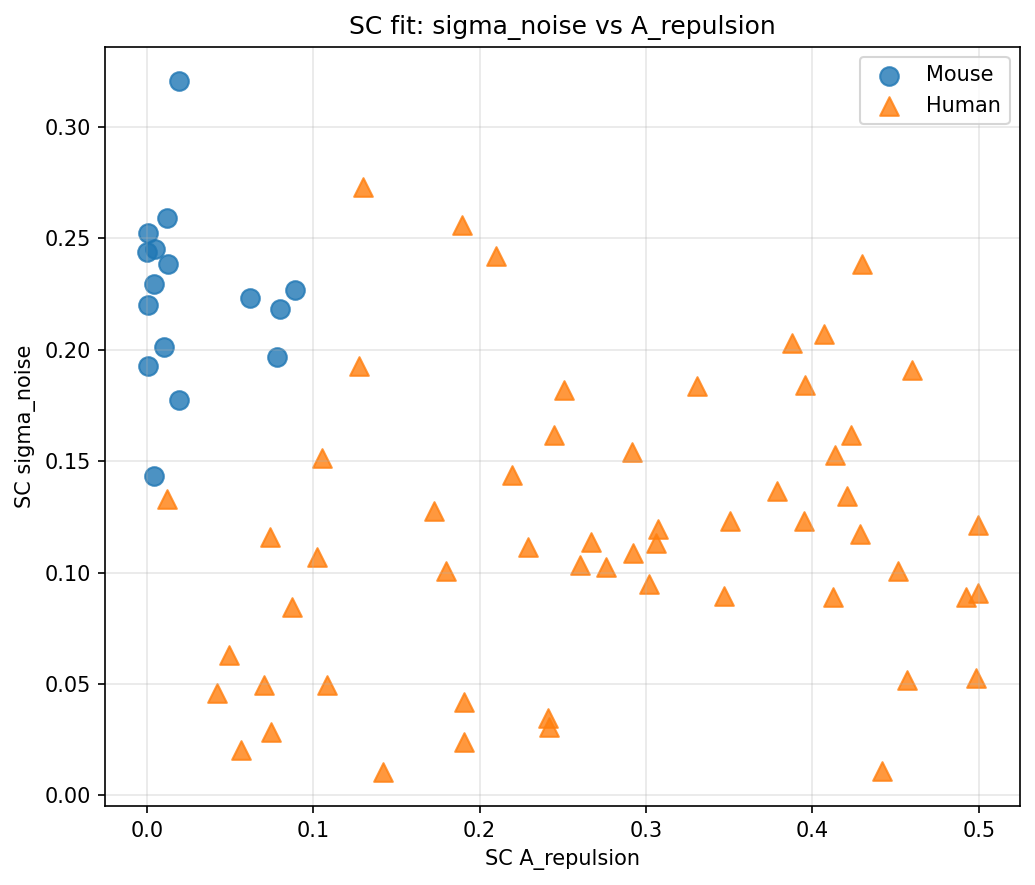

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\SC_noise_vs_repulsion.png


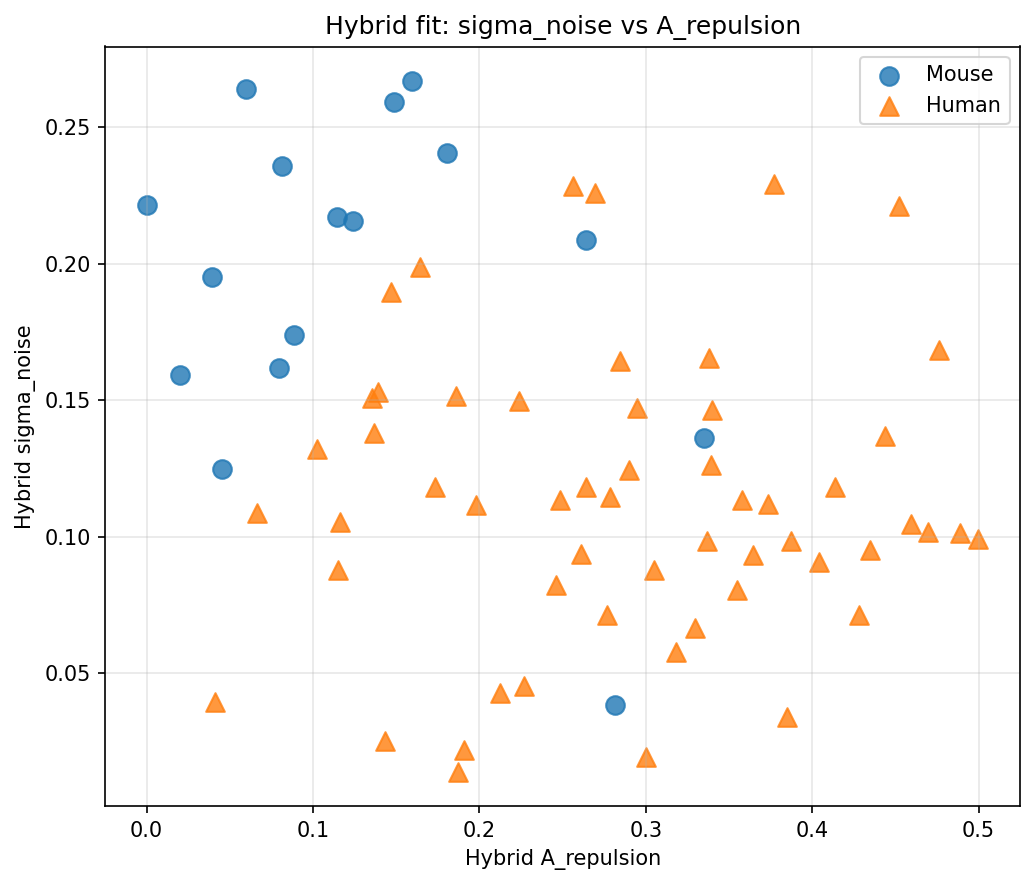

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\Hybrid_noise_vs_repulsion.png


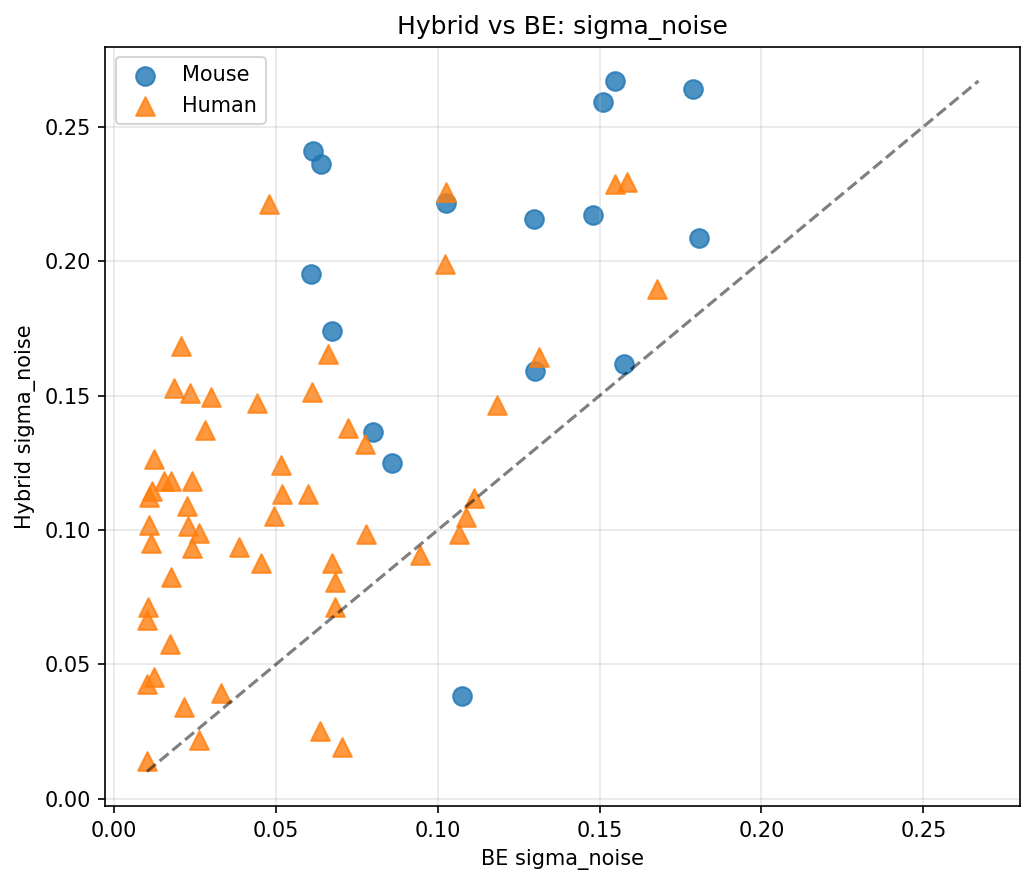

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\Hybrid_vs_BE_sigma_noise.png


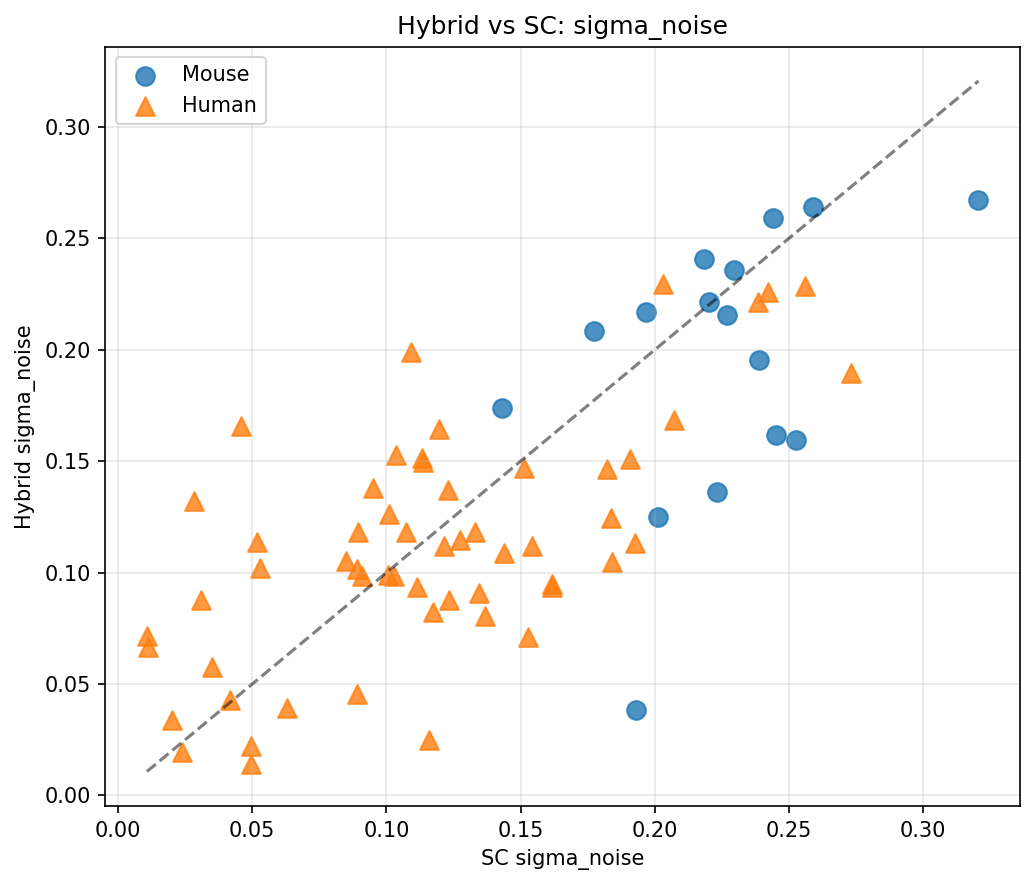

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\Hybrid_vs_SC_sigma_noise.png


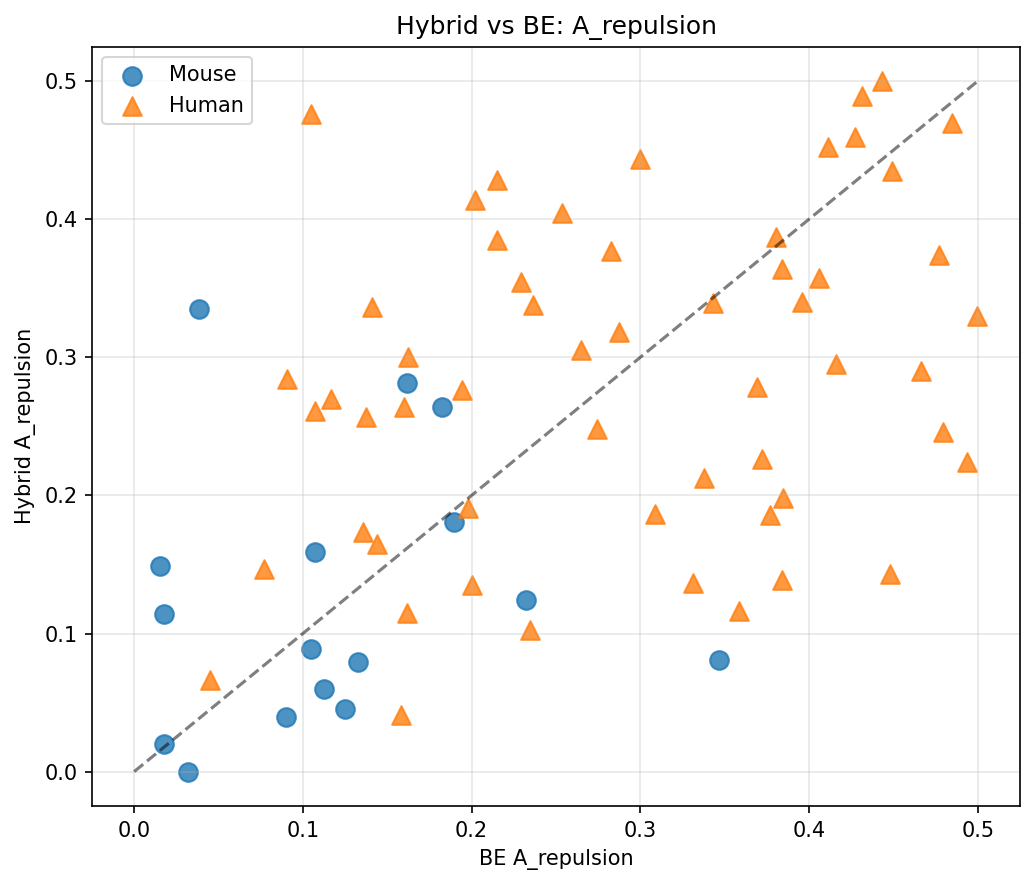

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\Hybrid_vs_BE_A_repulsion.png


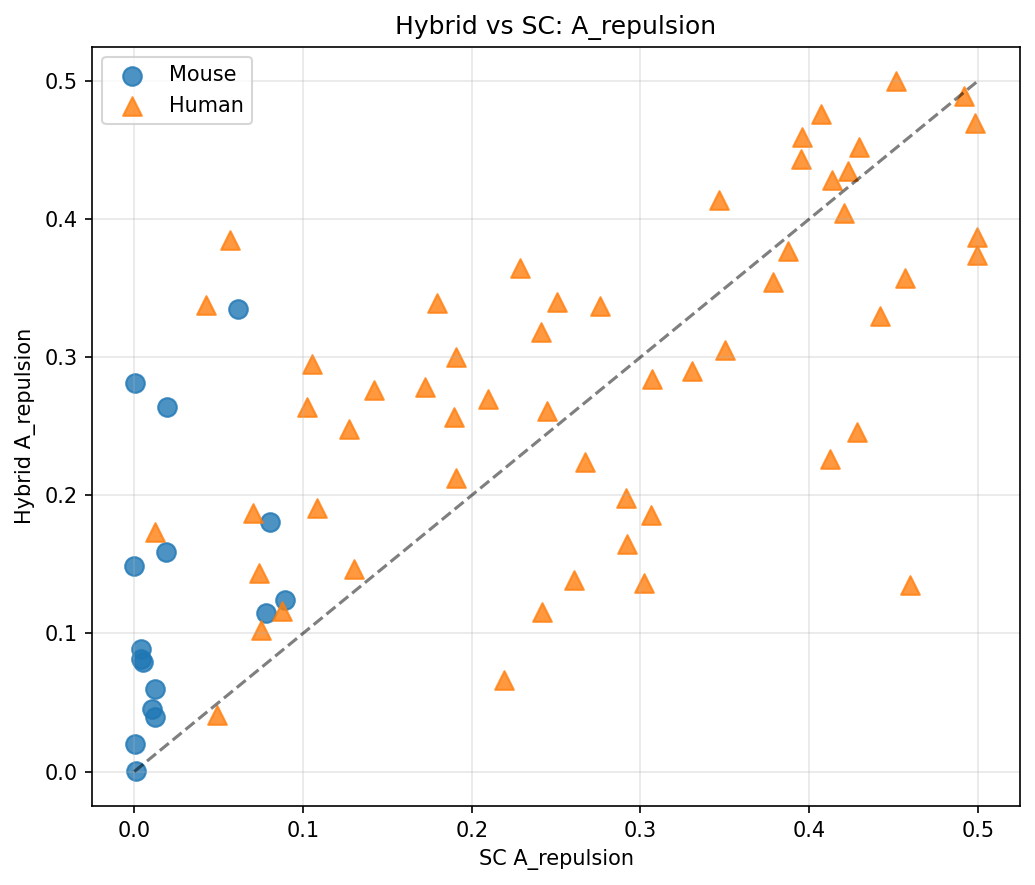

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\Hybrid_vs_SC_A_repulsion.png


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

save_dir = os.path.join(root_dir, "compensation_shared_parameter_plots")
os.makedirs(save_dir, exist_ok=True)

# =====================================================
# Helper plotting function
# =====================================================
def scatter_by_species(
    df,
    x_col,
    y_col,
    title,
    xlabel,
    ylabel,
    save_name,
    add_identity=False
):
    plt.figure(figsize=(7, 6), dpi=150)

    for species, marker in [("Mouse", "o"), ("Human", "^")]:
        sub = df[df["species"] == species]

        plt.scatter(
            sub[x_col],
            sub[y_col],
            marker=marker,
            s=80,
            alpha=0.8,
            label=species
        )

    if add_identity:
        vals = np.concatenate([
            df[x_col].dropna().to_numpy(),
            df[y_col].dropna().to_numpy()
        ])
        lo, hi = np.nanmin(vals), np.nanmax(vals)
        plt.plot([lo, hi], [lo, hi], "k--", alpha=0.5)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)


# =====================================================
# 1. Within-model noise vs repulsion
# =====================================================
scatter_by_species(
    df,
    x_col="BE_A_repulsion",
    y_col="BE_sigma_noise",
    title="BE fit: sigma_noise vs A_repulsion",
    xlabel="BE A_repulsion",
    ylabel="BE sigma_noise",
    save_name="BE_noise_vs_repulsion.png"
)

scatter_by_species(
    df,
    x_col="SC_A_repulsion",
    y_col="SC_sigma_noise",
    title="SC fit: sigma_noise vs A_repulsion",
    xlabel="SC A_repulsion",
    ylabel="SC sigma_noise",
    save_name="SC_noise_vs_repulsion.png"
)

scatter_by_species(
    df,
    x_col="Hybrid_A_repulsion",
    y_col="Hybrid_sigma_noise",
    title="Hybrid fit: sigma_noise vs A_repulsion",
    xlabel="Hybrid A_repulsion",
    ylabel="Hybrid sigma_noise",
    save_name="Hybrid_noise_vs_repulsion.png"
)


# =====================================================
# 2. Does Hybrid look like BE or SC in sigma_noise?
# =====================================================
scatter_by_species(
    df,
    x_col="BE_sigma_noise",
    y_col="Hybrid_sigma_noise",
    title="Hybrid vs BE: sigma_noise",
    xlabel="BE sigma_noise",
    ylabel="Hybrid sigma_noise",
    save_name="Hybrid_vs_BE_sigma_noise.png",
    add_identity=True
)

scatter_by_species(
    df,
    x_col="SC_sigma_noise",
    y_col="Hybrid_sigma_noise",
    title="Hybrid vs SC: sigma_noise",
    xlabel="SC sigma_noise",
    ylabel="Hybrid sigma_noise",
    save_name="Hybrid_vs_SC_sigma_noise.png",
    add_identity=True
)


# =====================================================
# 3. Does Hybrid look like BE or SC in A_repulsion?
# =====================================================
scatter_by_species(
    df,
    x_col="BE_A_repulsion",
    y_col="Hybrid_A_repulsion",
    title="Hybrid vs BE: A_repulsion",
    xlabel="BE A_repulsion",
    ylabel="Hybrid A_repulsion",
    save_name="Hybrid_vs_BE_A_repulsion.png",
    add_identity=True
)

scatter_by_species(
    df,
    x_col="SC_A_repulsion",
    y_col="Hybrid_A_repulsion",
    title="Hybrid vs SC: A_repulsion",
    xlabel="SC A_repulsion",
    ylabel="Hybrid A_repulsion",
    save_name="Hybrid_vs_SC_A_repulsion.png",
    add_identity=True
)

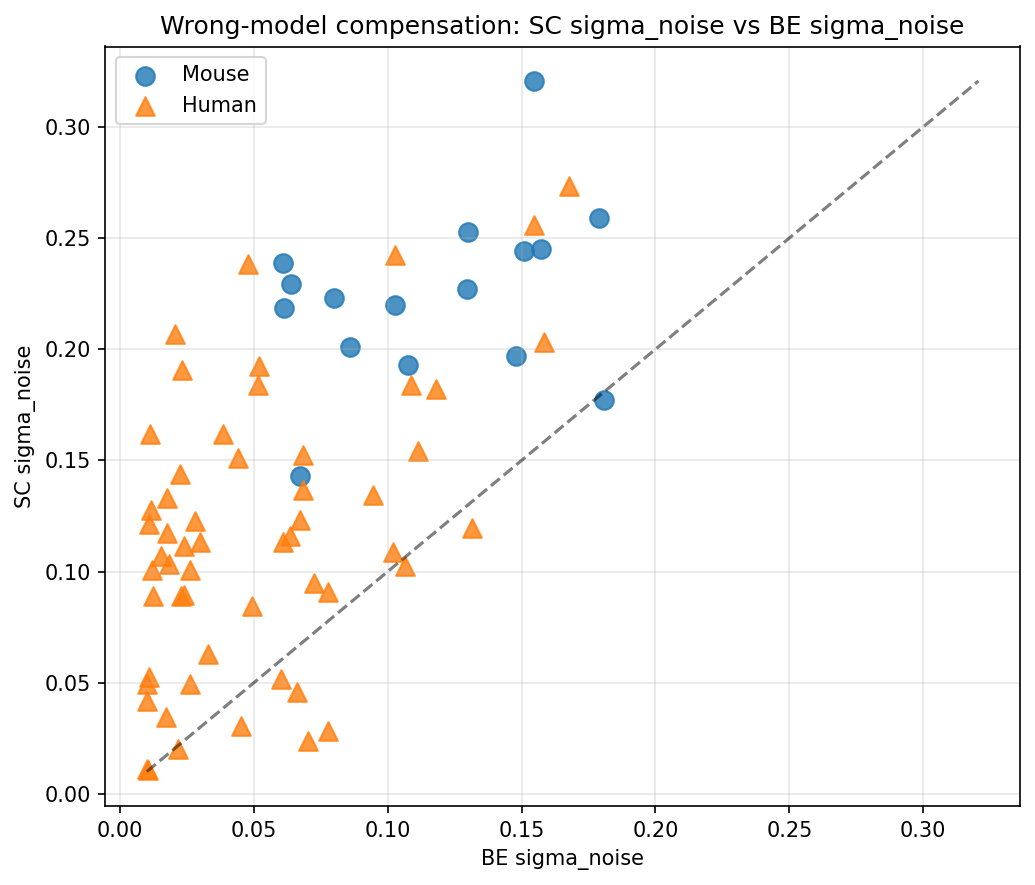

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\SC_vs_BE_sigma_noise_compensation.png


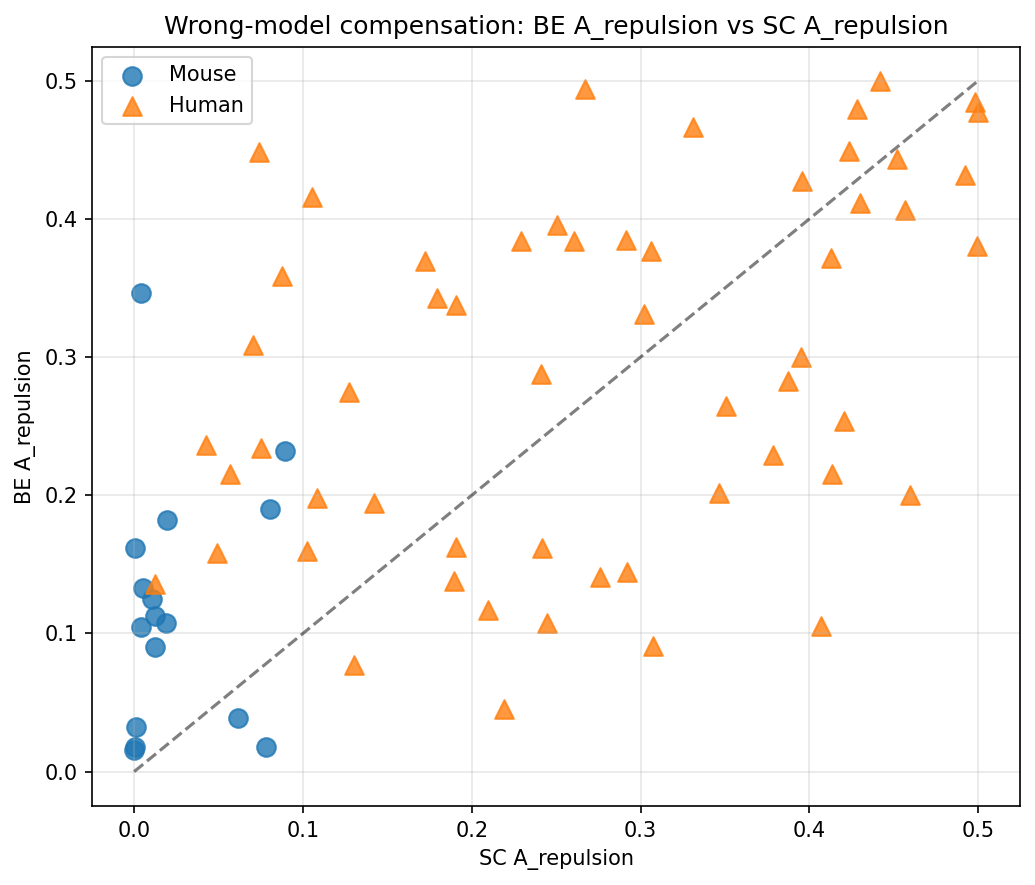

Saved: D:\sc_modelling-amir-2025\compensation_shared_parameter_plots\BE_vs_SC_A_repulsion_compensation.png


In [9]:
# =====================================================
# 4. Wrong-model compensation plots
# =====================================================

# If animal is BE-like, SC may increase noise to mimic shallow BE boundary uncertainty
scatter_by_species(
    df,
    x_col="BE_sigma_noise",
    y_col="SC_sigma_noise",
    title="Wrong-model compensation: SC sigma_noise vs BE sigma_noise",
    xlabel="BE sigma_noise",
    ylabel="SC sigma_noise",
    save_name="SC_vs_BE_sigma_noise_compensation.png",
    add_identity=True
)

# If animal is SC-like, BE may increase repulsion to mimic SC stripe-like structure
scatter_by_species(
    df,
    x_col="SC_A_repulsion",
    y_col="BE_A_repulsion",
    title="Wrong-model compensation: BE A_repulsion vs SC A_repulsion",
    xlabel="SC A_repulsion",
    ylabel="BE A_repulsion",
    save_name="BE_vs_SC_A_repulsion_compensation.png",
    add_identity=True
)

Loaded rows: 72


,species,subject,sampler,BE_sigma_noise,SC_sigma_noise,Hybrid_sigma_noise,BE_A_repulsion,SC_A_repulsion,Hybrid_A_repulsion,Hybrid_alpha
0,Mouse,QP0100,CMA-ES,0.154600,0.320580,0.267018,0.107447,0.019028,0.159319,0.464892
1,Mouse,QP0100,TPE,0.178864,0.258965,0.264220,0.112440,0.012271,0.059657,0.235859
2,Mouse,QP0101,CMA-ES,0.157399,0.245072,0.161774,0.132541,0.004993,0.079372,0.104290
3,Mouse,QP0101,TPE,0.129918,0.252505,0.159293,0.017628,0.000596,0.020300,0.213527
4,Mouse,QP0103,CMA-ES,0.063816,0.229467,0.235993,0.346322,0.004018,0.081240,0.626316


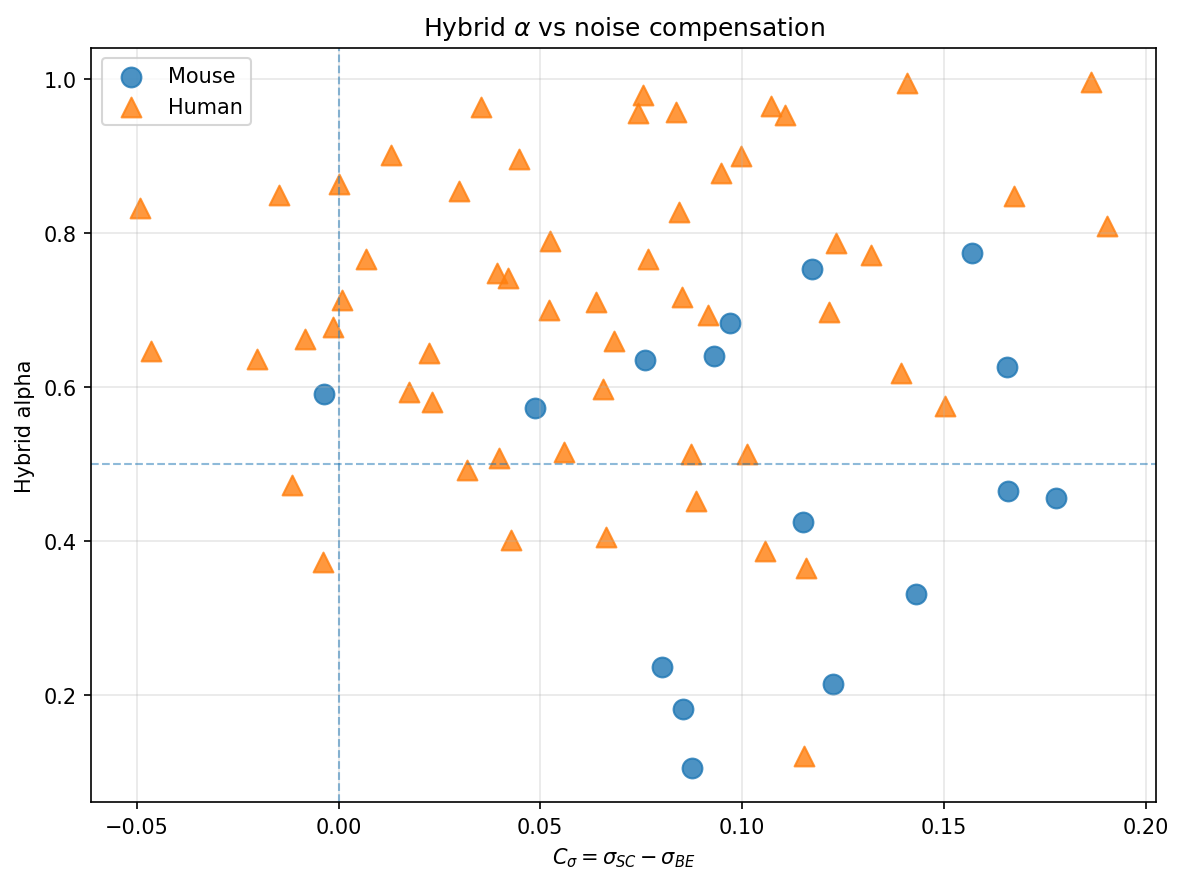

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_C_sigma.png


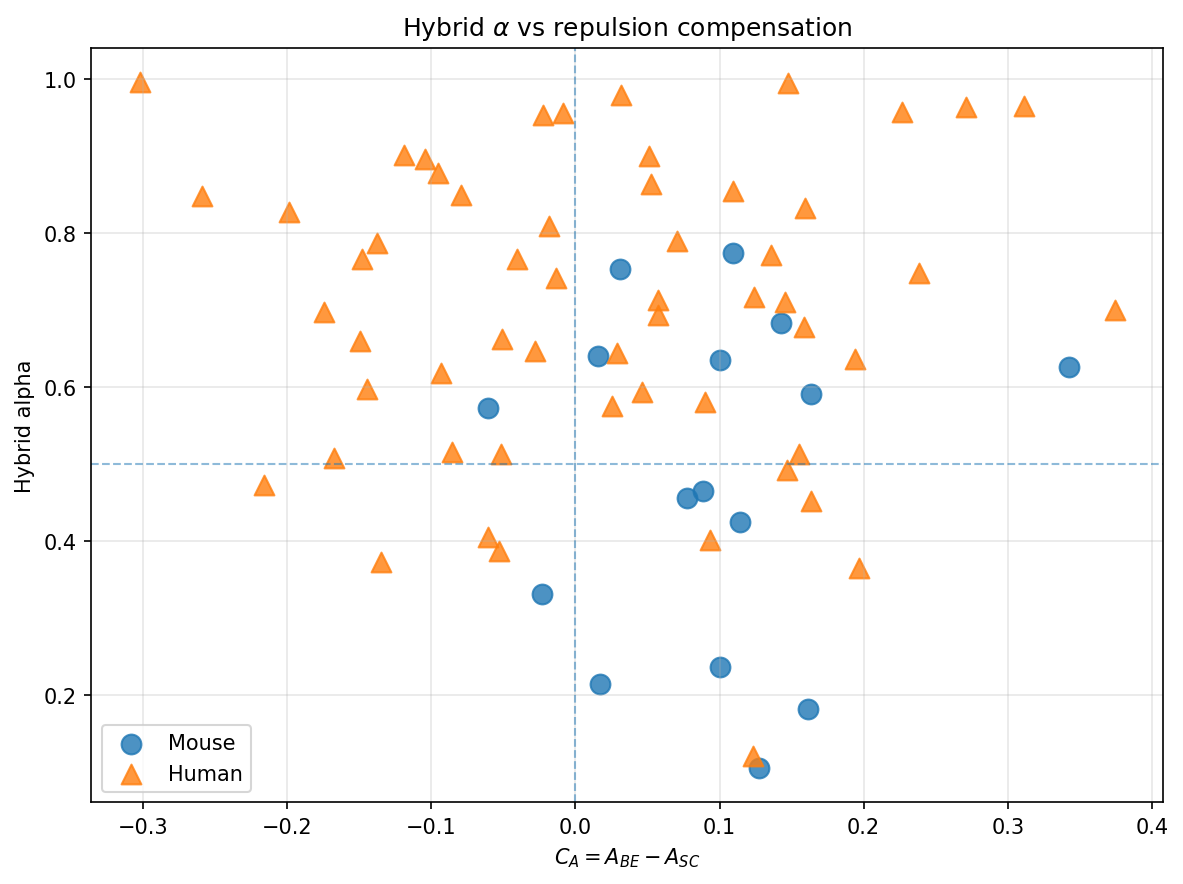

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_C_A.png


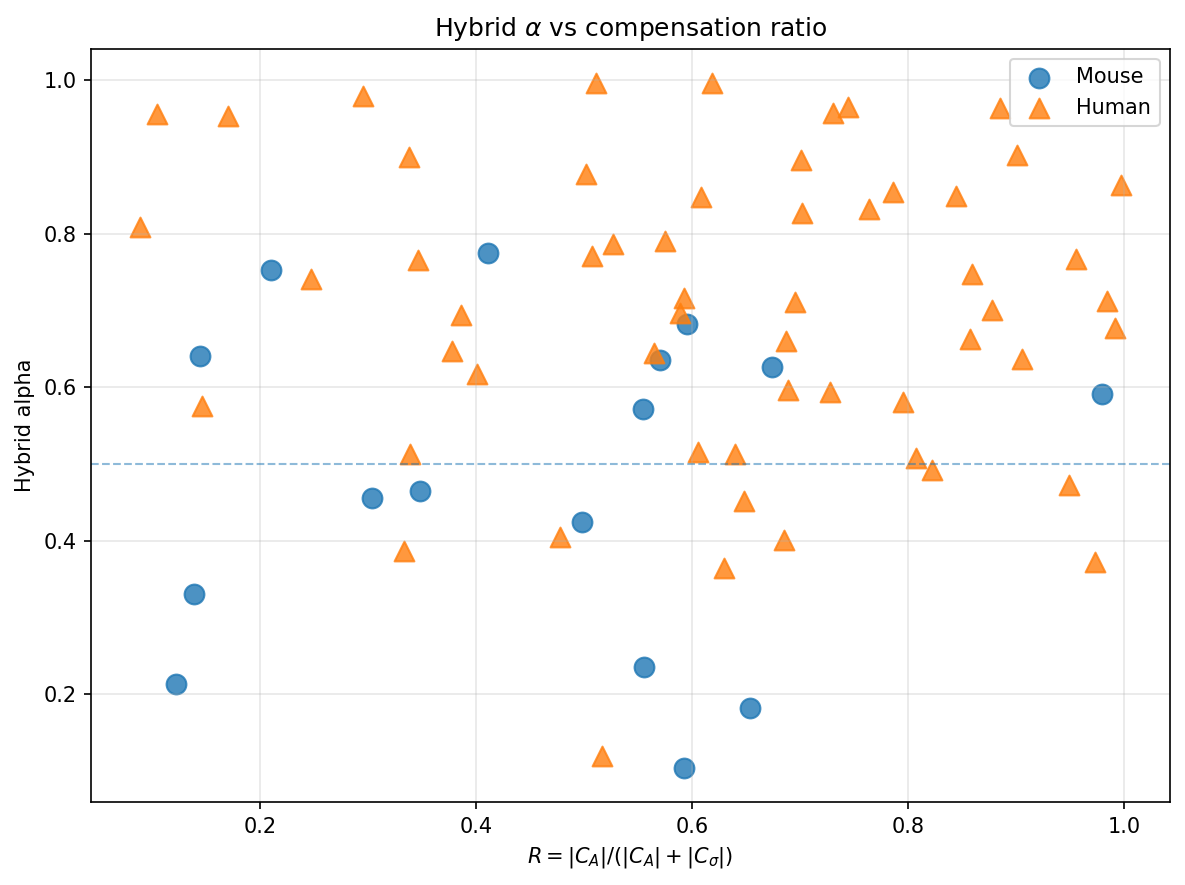

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_R_abs.png


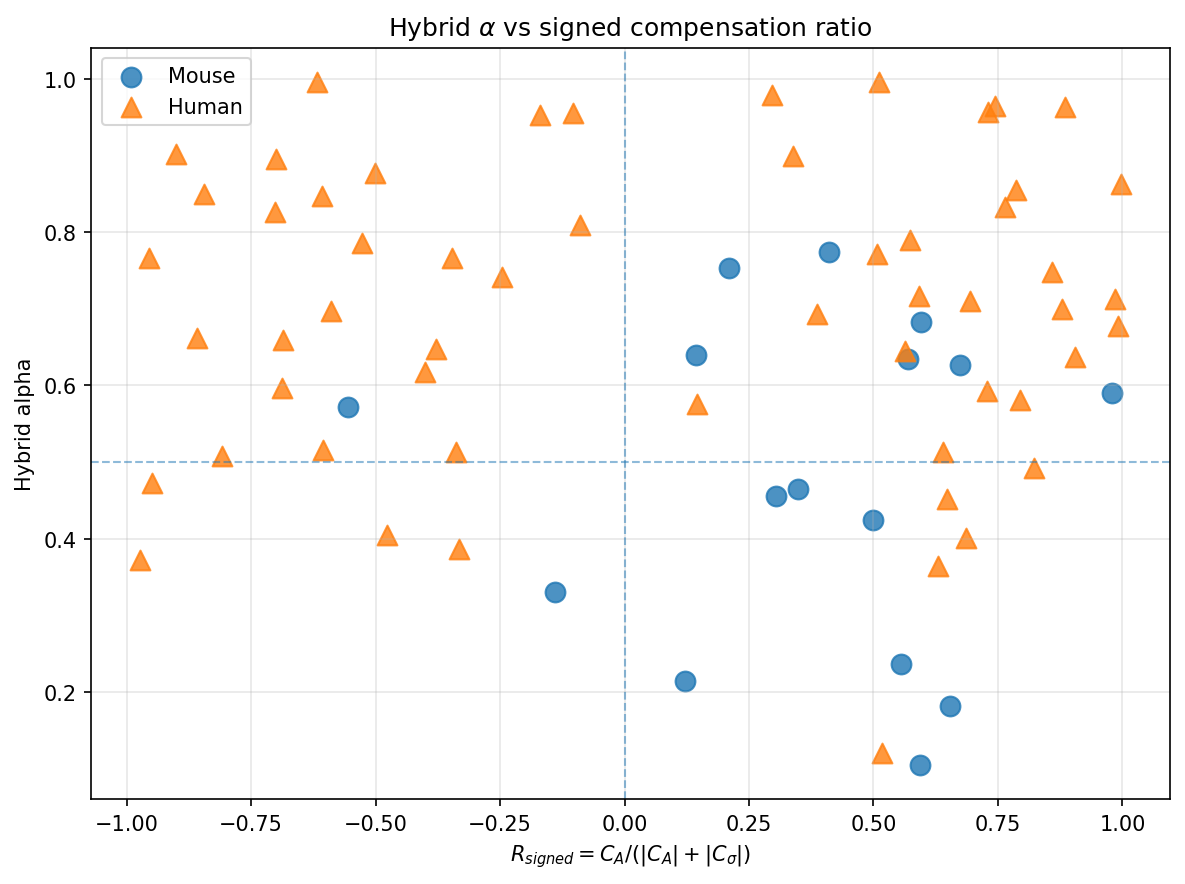

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_R_signed.png


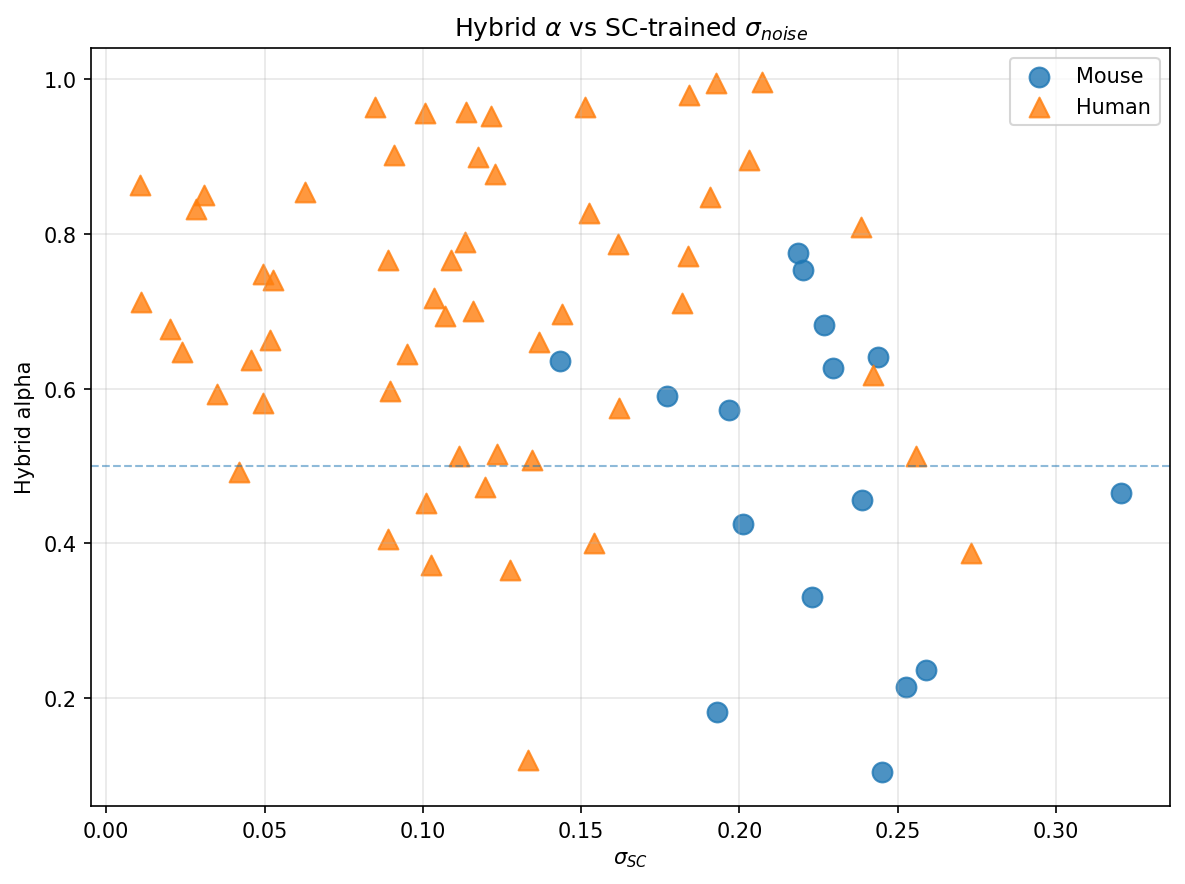

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_SC_sigma_noise.png


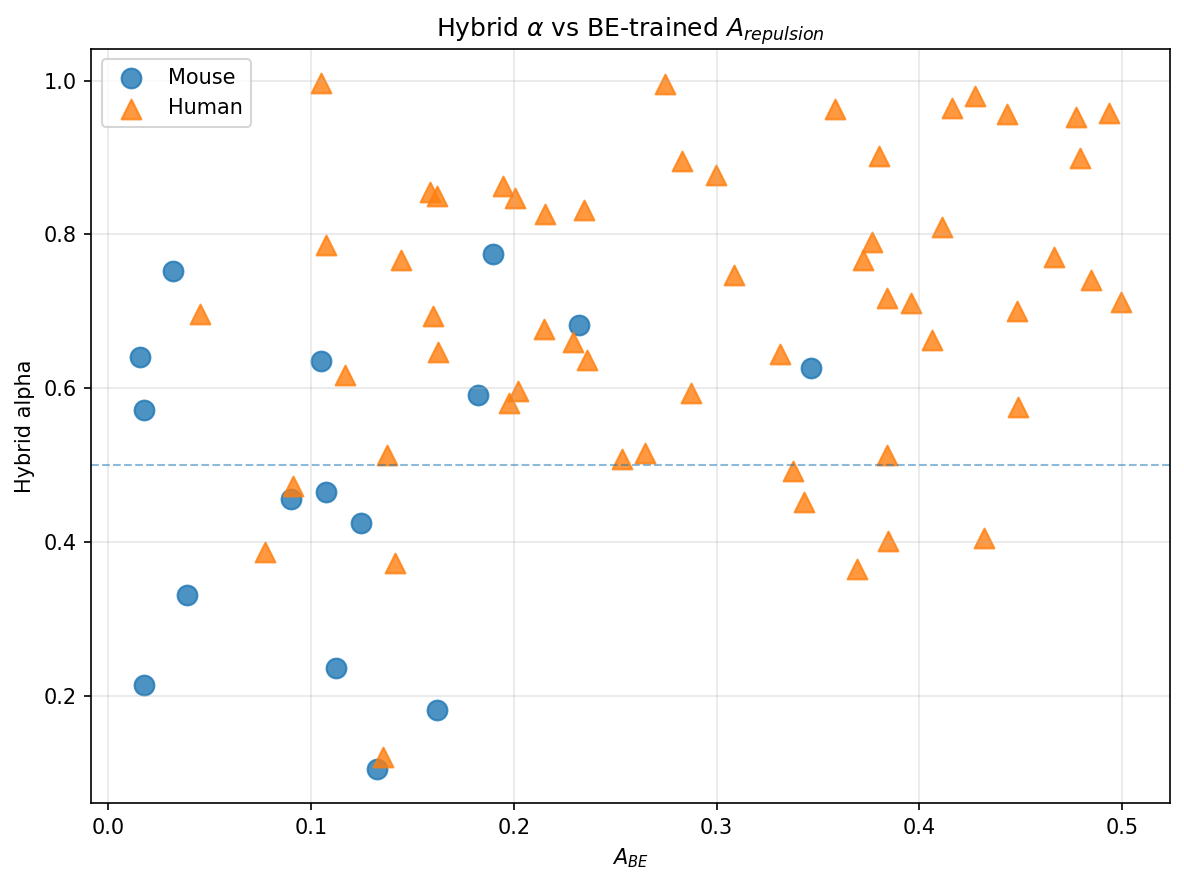

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\alpha_vs_BE_A_repulsion.png


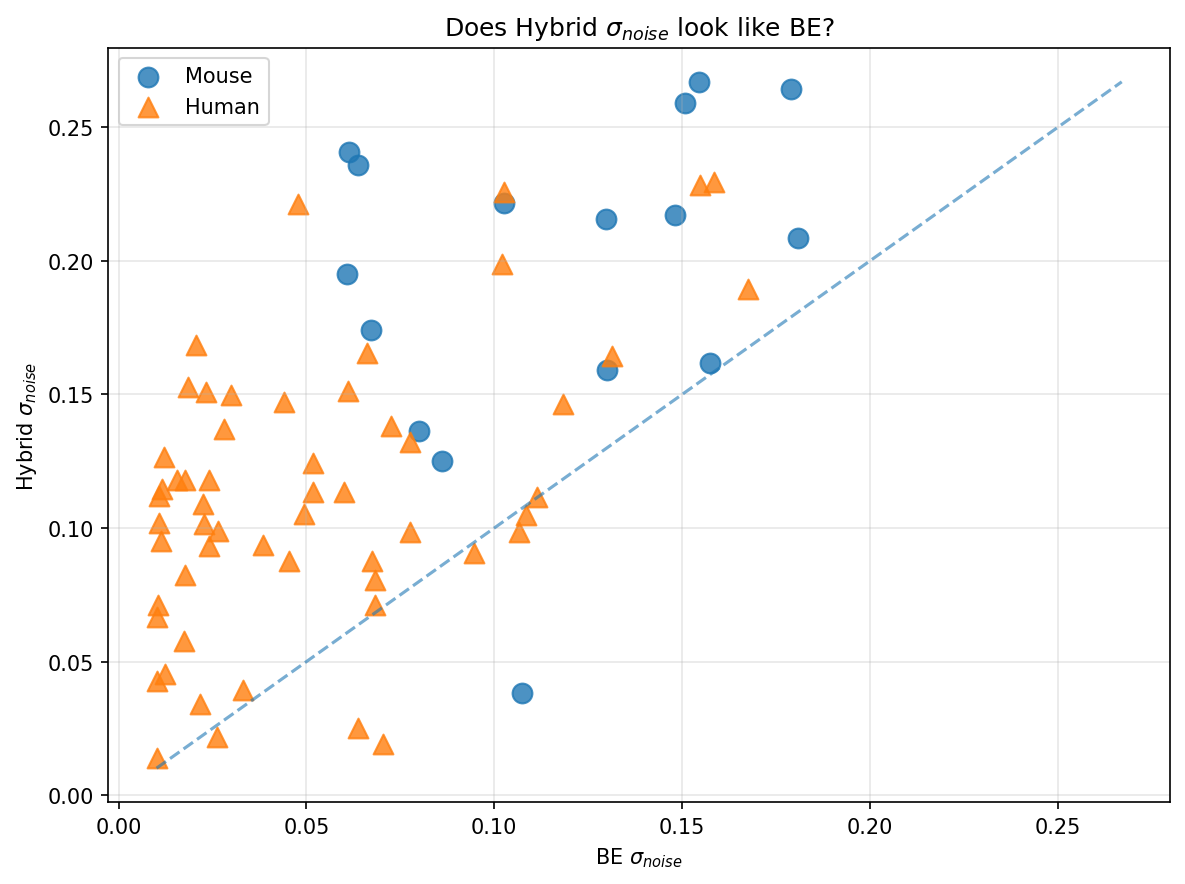

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\Hybrid_vs_BE_sigma_noise.png


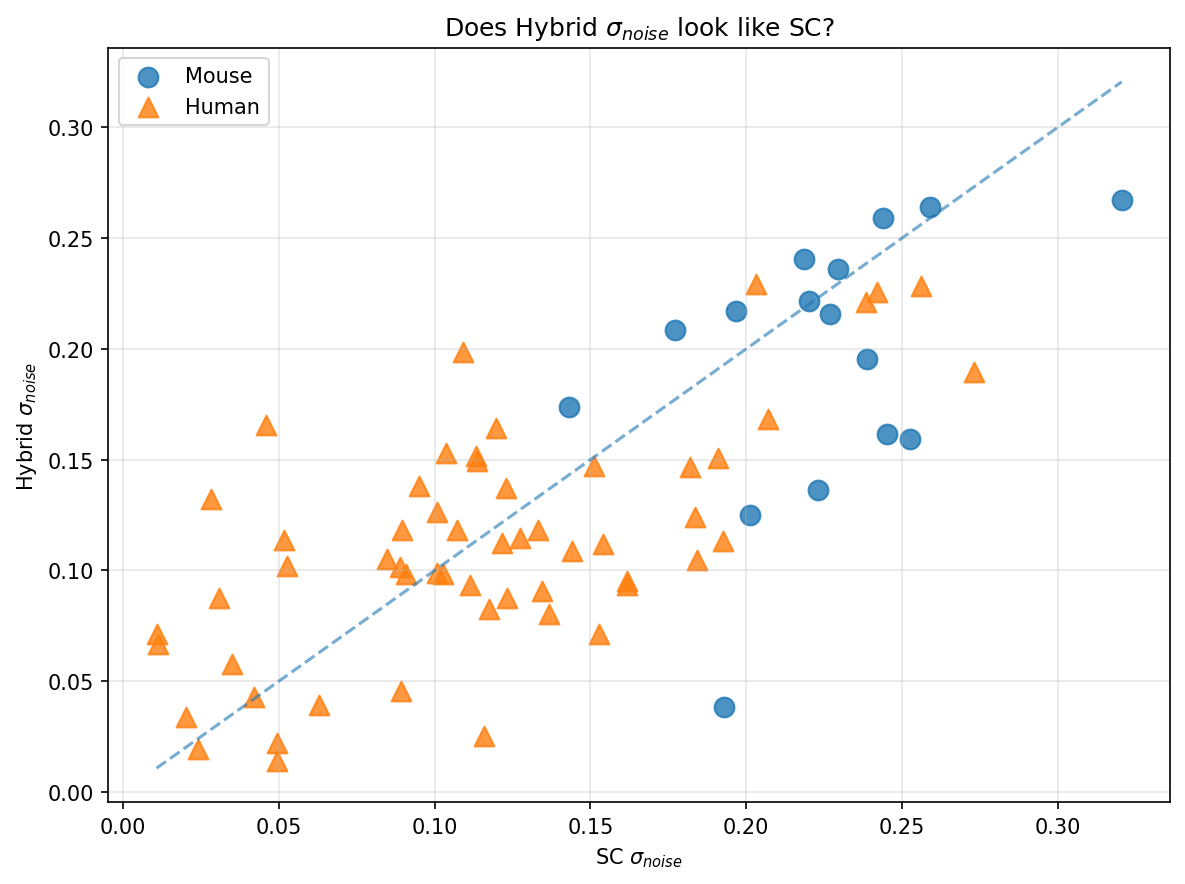

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\Hybrid_vs_SC_sigma_noise.png


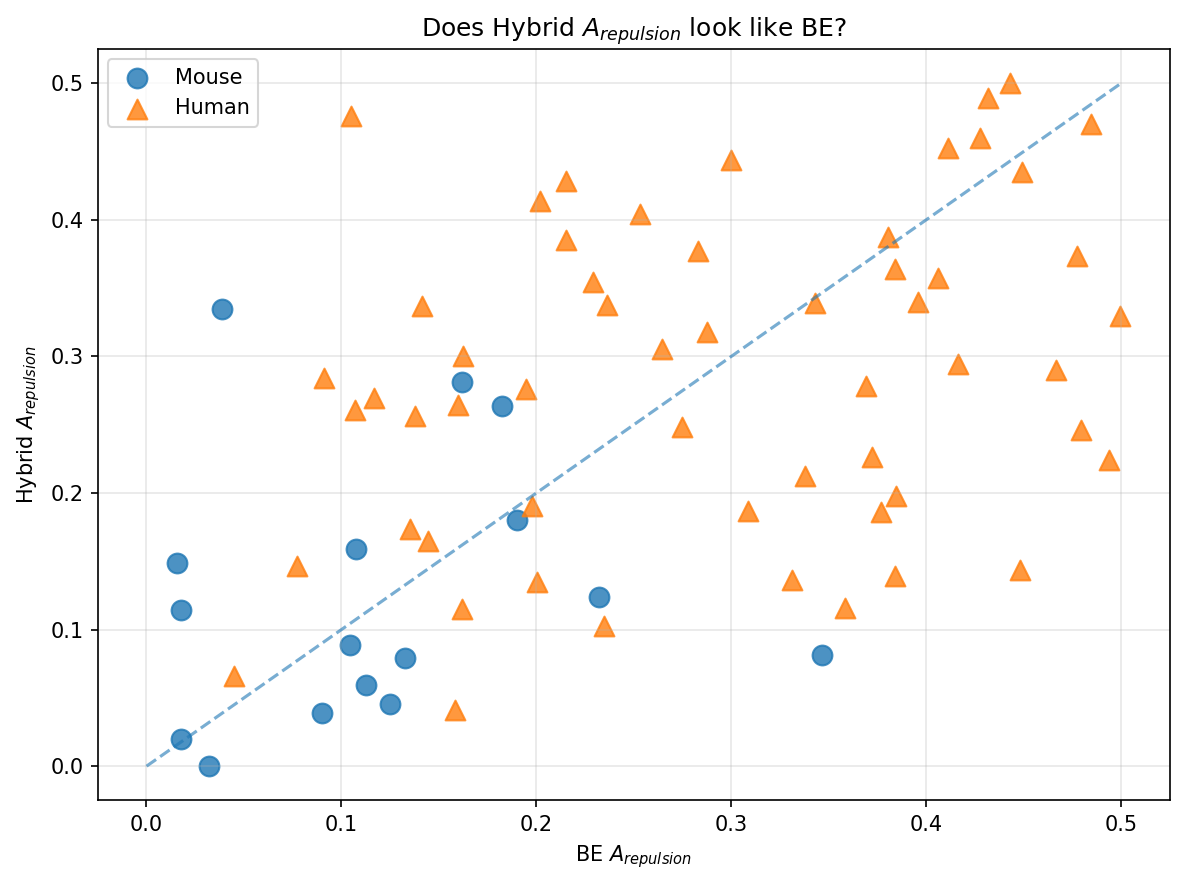

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\Hybrid_vs_BE_A_repulsion.png


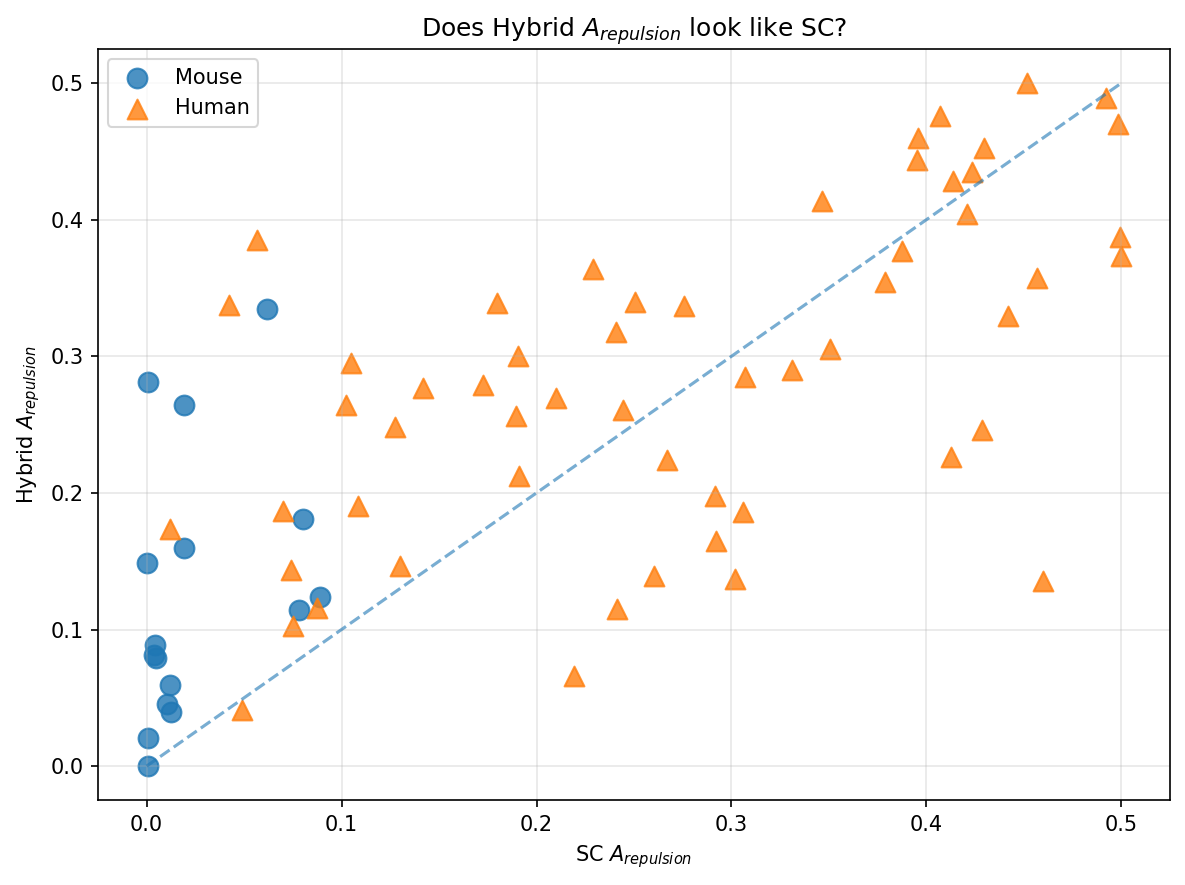

Saved: D:\sc_modelling-amir-2025\compensation_alpha_plots\Hybrid_vs_SC_A_repulsion.png


BE_sigma_noise                     SC_sigma_noise                      \
                  mean       std    median           mean       std    median   
species                                                                         
Human         0.052442  0.042153  0.041304       0.116868  0.063702  0.113451   
Mouse         0.116229  0.042853  0.118598       0.224297  0.039540  0.224938   

        Hybrid_sigma_noise                     BE_A_repulsion  ...   C_sigma  \
                      mean       std    median           mean  ...    median   
species                                                        ...             
Human             0.112611  0.052814  0.110273       0.292643  ...  0.065858   
Mouse             0.194992  0.060800  0.212108       0.119141  ...  0.106101   

              C_A                         R_abs                      R_signed  \
             mean       std    median      mean       std    median      mean   
species                                                                         
Human    0.018348  0.148786  0.027341  0.624806  0.242285  0.643811  0.074946   
Mouse    0.094241  0.092774  0.100293  0.459354  0.236574  0.526325  0.372718   

                             
              std    median  
species                      
Human    0.671166  0.220433  
Mouse    0.364500  0.454644  

[2 rows x 33 columns]

Saved:
D:\sc_modelling-amir-2025\compensation_alpha_plots\summary_statistics.csv
D:\sc_modelling-amir-2025\compensation_alpha_plots\summary_statistics_flat.csv
Species summaries saved.

Saved:
paired_tests.csv
correlations.csv
species_comparison_tests.csv


In [13]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Settings
# =====================================================
root_dir = r"D:\sc_modelling-amir-2025"

mouse_subjects = [
    "QP0100", "QP0101", "QP0103", "QP0121",
    "QP062", "QP063", "QP070", "QP071"
]

human_subjects = [
    '6363339', '6363334', '6363353', '6363338', '6363346', '6363343',
    '6363329', '6363354', '6363347', '6363328', '6363330', '6363341',
    '6363407', '6363430', '6363368', '6363349', '6363364', '6269773',
    '6269770', '6269757', '6269881', '6357507', '6357495', '6357501',
    '6357497', '6357556', '6357698', '6357829'
]

samplers = ["CMA-ES", "TPE"]

folders = {
    "BE": "Hybrid_BE_fit",
    "SC": "Hybrid_SC_fit",
    "Hybrid": "Hybrid_new3_fit",
}

save_dir = os.path.join(root_dir, "compensation_alpha_plots")
os.makedirs(save_dir, exist_ok=True)


# =====================================================
# Loading helpers
# =====================================================
def find_result_file(folder, species, subject, sampler):
    search_dir = os.path.join(
        root_dir,
        folder,
        species,
        "results",
        sampler,
        subject
    )

    patterns = [
        os.path.join(search_dir, f"*{subject}*{sampler}*.pkl"),
        os.path.join(search_dir, "*.pkl"),
    ]

    files = []
    for pattern in patterns:
        files.extend(glob.glob(pattern))

    files = sorted(set(files))

    if len(files) == 0:
        return None

    return files[0]


def extract_params(data):
    if not isinstance(data, dict):
        return None

    if "best_params" in data:
        return data["best_params"]

    if "best_params_per_fold" in data:
        fold_params = data["best_params_per_fold"]

        if isinstance(fold_params, list) and len(fold_params) > 0:
            keys = fold_params[0].keys()

            return {
                k: np.nanmean([
                    fp[k] for fp in fold_params
                    if isinstance(fp, dict) and k in fp
                ])
                for k in keys
            }

    return None


def load_params(folder, species, subject, sampler):
    path = find_result_file(folder, species, subject, sampler)

    if path is None:
        return None

    with open(path, "rb") as f:
        data = pickle.load(f)

    return extract_params(data)


# =====================================================
# Build dataframe
# =====================================================
rows = []

for species, subjects in [
    ("Mouse", mouse_subjects),
    ("Human", human_subjects)
]:
    for subject in subjects:
        for sampler in samplers:

            be_params = load_params(
                folders["BE"],
                species,
                subject,
                sampler
            )

            sc_params = load_params(
                folders["SC"],
                species,
                subject,
                sampler
            )

            hybrid_params = load_params(
                folders["Hybrid"],
                species,
                subject,
                sampler
            )

            if be_params is None or sc_params is None or hybrid_params is None:
                print("Missing:", species, subject, sampler)
                continue

            rows.append({
                "species": species,
                "subject": subject,
                "sampler": sampler,

                "BE_sigma_noise": be_params.get("sigma_noise", np.nan),
                "SC_sigma_noise": sc_params.get("sigma_noise", np.nan),
                "Hybrid_sigma_noise": hybrid_params.get("sigma_noise", np.nan),

                "BE_A_repulsion": be_params.get("A_repulsion", np.nan),
                "SC_A_repulsion": sc_params.get("A_repulsion", np.nan),
                "Hybrid_A_repulsion": hybrid_params.get("A_repulsion", np.nan),

                "Hybrid_alpha": hybrid_params.get("alpha", np.nan),
            })

df = pd.DataFrame(rows)

print("Loaded rows:", len(df))
display(df.head())

if len(df) == 0:
    raise ValueError("No files were loaded. Check folder structure.")


# =====================================================
# Compensation indices
# =====================================================
df["C_sigma"] = df["SC_sigma_noise"] - df["BE_sigma_noise"]
df["C_A"] = df["BE_A_repulsion"] - df["SC_A_repulsion"]

eps = 1e-8

df["R_abs"] = (
    np.abs(df["C_A"]) /
    (
        np.abs(df["C_A"])
        + np.abs(df["C_sigma"])
        + eps
    )
)

df["R_signed"] = (
    df["C_A"] /
    (
        np.abs(df["C_A"])
        + np.abs(df["C_sigma"])
        + eps
    )
)


# =====================================================
# Plot helper
# =====================================================
def plot_alpha_vs(
    df,
    x_col,
    xlabel,
    title,
    save_name,
    add_hline=True,
    add_vline=True
):
    plt.figure(figsize=(8, 6), dpi=150)

    for species, marker in [
        ("Mouse", "o"),
        ("Human", "^")
    ]:
        sub = df[df["species"] == species]

        plt.scatter(
            sub[x_col],
            sub["Hybrid_alpha"],
            marker=marker,
            s=90,
            alpha=0.8,
            label=species
        )

    if add_hline:
        plt.axhline(
            0.5,
            linestyle="--",
            linewidth=1,
            alpha=0.5
        )

    if add_vline:
        plt.axvline(
            0,
            linestyle="--",
            linewidth=1,
            alpha=0.5
        )

    plt.xlabel(xlabel)
    plt.ylabel("Hybrid alpha")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = os.path.join(save_dir, save_name)
    plt.savefig(path, dpi=300)
    plt.show()

    print("Saved:", path)


def plot_identity(
    df,
    x_col,
    y_col,
    xlabel,
    ylabel,
    title,
    save_name
):
    plt.figure(figsize=(8, 6), dpi=150)

    for species, marker in [
        ("Mouse", "o"),
        ("Human", "^")
    ]:
        sub = df[df["species"] == species]

        plt.scatter(
            sub[x_col],
            sub[y_col],
            marker=marker,
            s=90,
            alpha=0.8,
            label=species
        )

    vals = np.concatenate([
        df[x_col].dropna().to_numpy(),
        df[y_col].dropna().to_numpy()
    ])

    lo = np.nanmin(vals)
    hi = np.nanmax(vals)

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        linewidth=1.5,
        alpha=0.6
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = os.path.join(save_dir, save_name)
    plt.savefig(path, dpi=300)
    plt.show()

    print("Saved:", path)


# =====================================================
# Main compensation hypothesis plots
# =====================================================

plot_alpha_vs(
    df,
    x_col="C_sigma",
    xlabel=r"$C_\sigma = \sigma_{SC} - \sigma_{BE}$",
    title=r"Hybrid $\alpha$ vs noise compensation",
    save_name="alpha_vs_C_sigma.png"
)

plot_alpha_vs(
    df,
    x_col="C_A",
    xlabel=r"$C_A = A_{BE} - A_{SC}$",
    title=r"Hybrid $\alpha$ vs repulsion compensation",
    save_name="alpha_vs_C_A.png"
)

plot_alpha_vs(
    df,
    x_col="R_abs",
    xlabel=r"$R = |C_A| / (|C_A| + |C_\sigma|)$",
    title=r"Hybrid $\alpha$ vs compensation ratio",
    save_name="alpha_vs_R_abs.png",
    add_vline=False
)

plot_alpha_vs(
    df,
    x_col="R_signed",
    xlabel=r"$R_{signed} = C_A / (|C_A| + |C_\sigma|)$",
    title=r"Hybrid $\alpha$ vs signed compensation ratio",
    save_name="alpha_vs_R_signed.png"
)


# =====================================================
# Direct simpler checks
# =====================================================

plot_alpha_vs(
    df,
    x_col="SC_sigma_noise",
    xlabel=r"$\sigma_{SC}$",
    title=r"Hybrid $\alpha$ vs SC-trained $\sigma_{noise}$",
    save_name="alpha_vs_SC_sigma_noise.png",
    add_vline=False
)

plot_alpha_vs(
    df,
    x_col="BE_A_repulsion",
    xlabel=r"$A_{BE}$",
    title=r"Hybrid $\alpha$ vs BE-trained $A_{repulsion}$",
    save_name="alpha_vs_BE_A_repulsion.png",
    add_vline=False
)


# =====================================================
# Direct Hybrid similarity checks
# =====================================================

plot_identity(
    df,
    x_col="BE_sigma_noise",
    y_col="Hybrid_sigma_noise",
    xlabel=r"BE $\sigma_{noise}$",
    ylabel=r"Hybrid $\sigma_{noise}$",
    title=r"Does Hybrid $\sigma_{noise}$ look like BE?",
    save_name="Hybrid_vs_BE_sigma_noise.png"
)

plot_identity(
    df,
    x_col="SC_sigma_noise",
    y_col="Hybrid_sigma_noise",
    xlabel=r"SC $\sigma_{noise}$",
    ylabel=r"Hybrid $\sigma_{noise}$",
    title=r"Does Hybrid $\sigma_{noise}$ look like SC?",
    save_name="Hybrid_vs_SC_sigma_noise.png"
)

plot_identity(
    df,
    x_col="BE_A_repulsion",
    y_col="Hybrid_A_repulsion",
    xlabel=r"BE $A_{repulsion}$",
    ylabel=r"Hybrid $A_{repulsion}$",
    title=r"Does Hybrid $A_{repulsion}$ look like BE?",
    save_name="Hybrid_vs_BE_A_repulsion.png"
)

plot_identity(
    df,
    x_col="SC_A_repulsion",
    y_col="Hybrid_A_repulsion",
    xlabel=r"SC $A_{repulsion}$",
    ylabel=r"Hybrid $A_{repulsion}$",
    title=r"Does Hybrid $A_{repulsion}$ look like SC?",
    save_name="Hybrid_vs_SC_A_repulsion.png"
)


# =====================================================
# Summary table
# =====================================================
summary = df.groupby("species")[
    [
        "BE_sigma_noise",
        "SC_sigma_noise",
        "Hybrid_sigma_noise",
        "BE_A_repulsion",
        "SC_A_repulsion",
        "Hybrid_A_repulsion",
        "Hybrid_alpha",
        "C_sigma",
        "C_A",
        "R_abs",
        "R_signed"
    ]
].agg(["mean", "std", "median"])

display(summary)

# ==========================================
# Save summary tables
# ==========================================

# Full multi-index summary
summary.to_csv(
    os.path.join(save_dir, "summary_statistics.csv")
)

# Flatten column names
summary_flat = summary.copy()
summary_flat.columns = [
    f"{col[0]}_{col[1]}"
    for col in summary_flat.columns
]

summary_flat.reset_index(inplace=True)

summary_flat.to_csv(
    os.path.join(save_dir, "summary_statistics_flat.csv"),
    index=False
)

print("Saved:")
print(os.path.join(save_dir, "summary_statistics.csv"))
print(os.path.join(save_dir, "summary_statistics_flat.csv"))


# ==========================================
# Species-specific summaries
# ==========================================

for species in df["species"].unique():

    species_df = df[df["species"] == species]

    species_summary = species_df[
        [
            "BE_sigma_noise",
            "SC_sigma_noise",
            "Hybrid_sigma_noise",
            "BE_A_repulsion",
            "SC_A_repulsion",
            "Hybrid_A_repulsion",
            "Hybrid_alpha",
            "C_sigma",
            "C_A",
            "R_abs",
            "R_signed"
        ]
    ].agg(["mean", "std", "median"])

    species_summary.to_csv(
        os.path.join(save_dir, f"{species}_summary.csv")
    )

print("Species summaries saved.")


from scipy.stats import wilcoxon, spearmanr, mannwhitneyu

# =====================================================
# Paired tests within species
# =====================================================
paired_results = []

variables = [
    ("sigma_noise", "BE_sigma_noise", "SC_sigma_noise"),
    ("sigma_noise", "BE_sigma_noise", "Hybrid_sigma_noise"),
    ("sigma_noise", "SC_sigma_noise", "Hybrid_sigma_noise"),

    ("A_repulsion", "BE_A_repulsion", "SC_A_repulsion"),
    ("A_repulsion", "BE_A_repulsion", "Hybrid_A_repulsion"),
    ("A_repulsion", "SC_A_repulsion", "Hybrid_A_repulsion"),
]

for species in df["species"].unique():

    species_df = df[df["species"] == species]

    for variable, col1, col2 in variables:

        x = species_df[col1]
        y = species_df[col2]

        try:
            stat, p = wilcoxon(x, y)
        except:
            stat, p = np.nan, np.nan

        paired_results.append({
            "species": species,
            "variable": variable,
            "comparison": f"{col1} vs {col2}",
            "test": "Wilcoxon signed-rank",
            "statistic": stat,
            "p_value": p
        })

paired_df = pd.DataFrame(paired_results)

paired_df.to_csv(
    os.path.join(save_dir, "paired_tests.csv"),
    index=False
)

# =====================================================
# Correlations
# =====================================================
corr_results = []

pairs = [

    ("Hybrid_alpha", "C_sigma"),
    ("Hybrid_alpha", "C_A"),
    ("Hybrid_alpha", "R_abs"),
    ("Hybrid_alpha", "R_signed"),

    ("Hybrid_alpha", "SC_sigma_noise"),
    ("Hybrid_alpha", "BE_A_repulsion"),

    ("Hybrid_sigma_noise", "BE_sigma_noise"),
    ("Hybrid_sigma_noise", "SC_sigma_noise"),

    ("Hybrid_A_repulsion", "BE_A_repulsion"),
    ("Hybrid_A_repulsion", "SC_A_repulsion")
]

for species in df["species"].unique():

    species_df = df[df["species"] == species]

    for xcol, ycol in pairs:

        rho, p = spearmanr(
            species_df[xcol],
            species_df[ycol]
        )

        corr_results.append({
            "species": species,
            "x": xcol,
            "y": ycol,
            "rho": rho,
            "p_value": p
        })

corr_df = pd.DataFrame(corr_results)

corr_df.to_csv(
    os.path.join(save_dir, "correlations.csv"),
    index=False
)

# =====================================================
# Mouse vs Human comparisons
# =====================================================
species_results = []

variables = [
    "Hybrid_alpha",
    "C_sigma",
    "C_A",
    "R_abs",
    "R_signed",

    "BE_sigma_noise",
    "SC_sigma_noise",
    "Hybrid_sigma_noise",

    "BE_A_repulsion",
    "SC_A_repulsion",
    "Hybrid_A_repulsion"
]

mouse_df = df[df["species"] == "Mouse"]
human_df = df[df["species"] == "Human"]

for var in variables:

    try:
        stat, p = mannwhitneyu(
            mouse_df[var],
            human_df[var],
            alternative="two-sided"
        )
    except:
        stat, p = np.nan, np.nan

    species_results.append({
        "variable": var,
        "test": "Mann-Whitney U",
        "statistic": stat,
        "p_value": p
    })

species_df = pd.DataFrame(species_results)

species_df.to_csv(
    os.path.join(save_dir, "species_comparison_tests.csv"),
    index=False
)

print()
print("Saved:")
print("paired_tests.csv")
print("correlations.csv")
print("species_comparison_tests.csv")


Loaded rows: 72


,species,subject,sampler,BE_train_error,SC_train_error,Hybrid_train_error,BE_sigma_noise,SC_sigma_noise,Hybrid_sigma_noise,BE_A_repulsion,SC_A_repulsion,Hybrid_A_repulsion,Hybrid_alpha,BE_file,SC_file,Hybrid_file
0,Mouse,QP0100,CMA-ES,0.009843,0.010779,0.007153,0.154600,0.320580,0.267018,0.107447,0.019028,0.159319,0.464892,D:\sc_modelling-amir-2025\Hybrid_BE_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_SC_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_new3_fit\Mous...
1,Mouse,QP0100,TPE,0.009342,0.010429,0.006532,0.178864,0.258965,0.264220,0.112440,0.012271,0.059657,0.235859,D:\sc_modelling-amir-2025\Hybrid_BE_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_SC_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_new3_fit\Mous...
2,Mouse,QP0101,CMA-ES,0.013661,0.035908,0.012826,0.157399,0.245072,0.161774,0.132541,0.004993,0.079372,0.104290,D:\sc_modelling-amir-2025\Hybrid_BE_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_SC_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_new3_fit\Mous...
3,Mouse,QP0101,TPE,0.010012,0.034436,0.016465,0.129918,0.252505,0.159293,0.017628,0.000596,0.020300,0.213527,D:\sc_modelling-amir-2025\Hybrid_BE_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_SC_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_new3_fit\Mous...
4,Mouse,QP0103,CMA-ES,0.022364,0.016082,0.011434,0.063816,0.229467,0.235993,0.346322,0.004018,0.081240,0.626316,D:\sc_modelling-amir-2025\Hybrid_BE_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_SC_fit\Mouse\...,D:\sc_modelling-amir-2025\Hybrid_new3_fit\Mous...


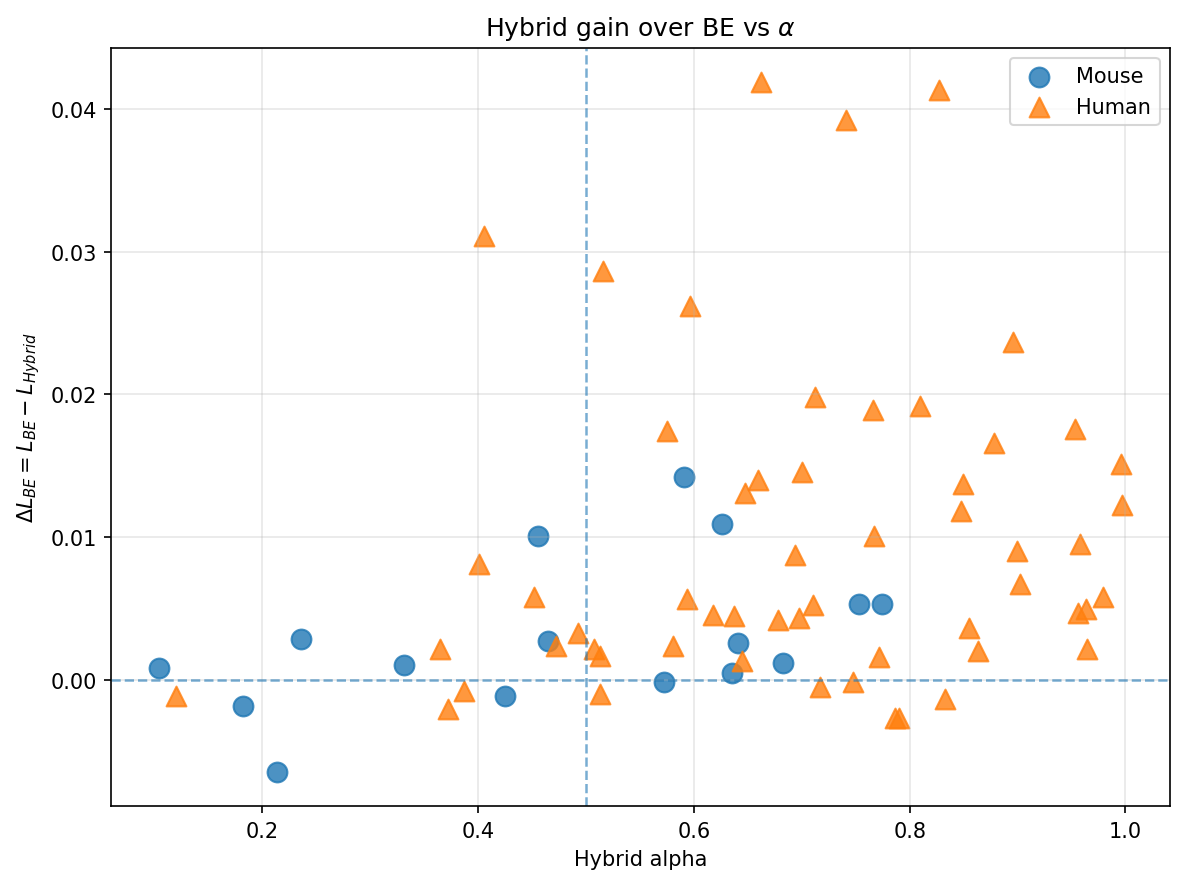

Saved: D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\DeltaL_BE_vs_alpha.png


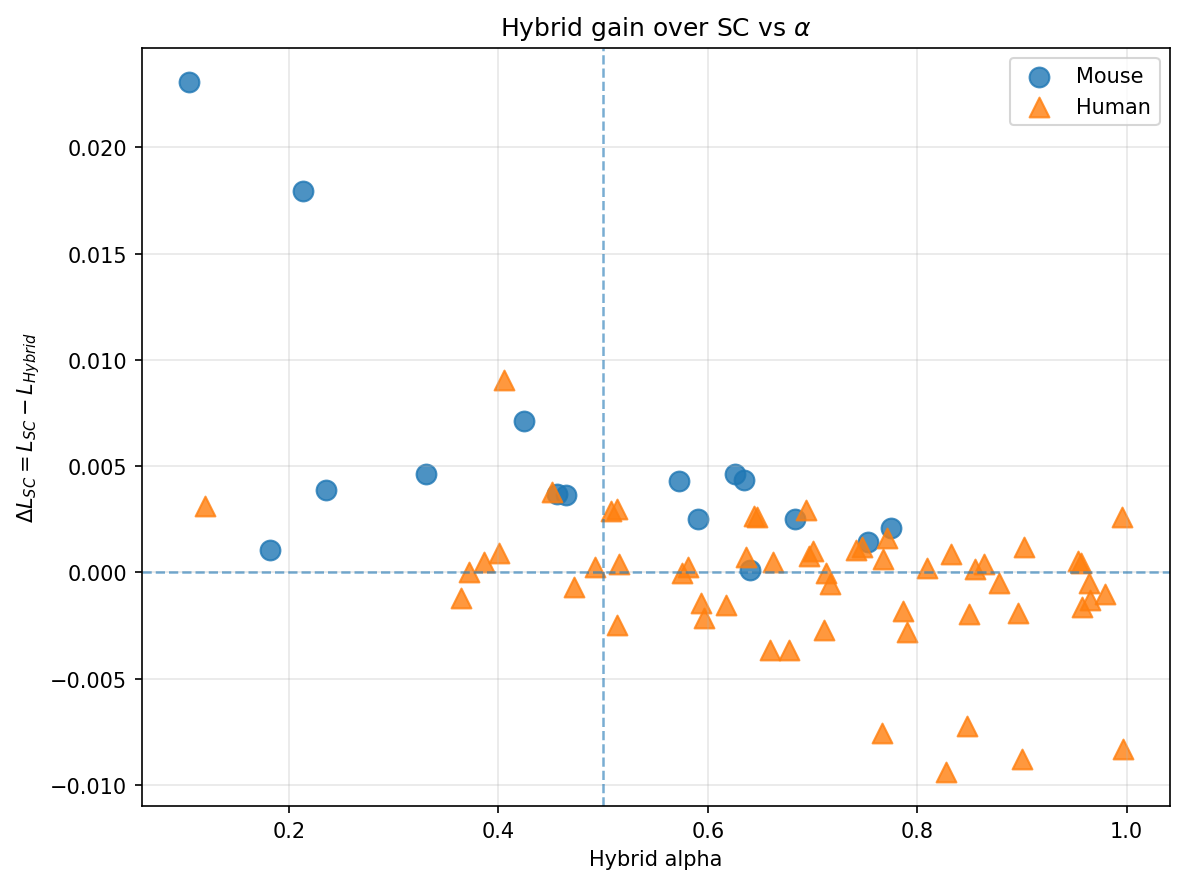

Saved: D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\DeltaL_SC_vs_alpha.png


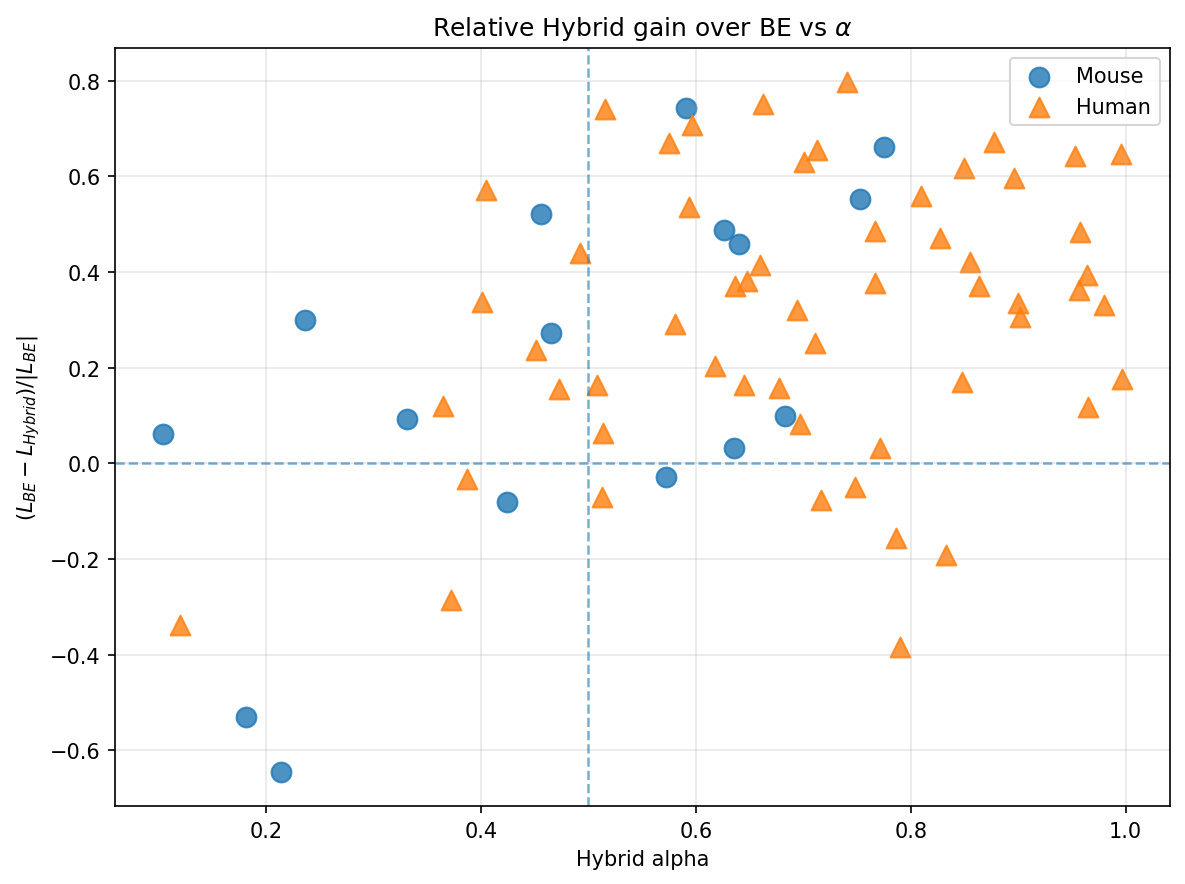

Saved: D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\Relative_gain_over_BE_vs_alpha.png


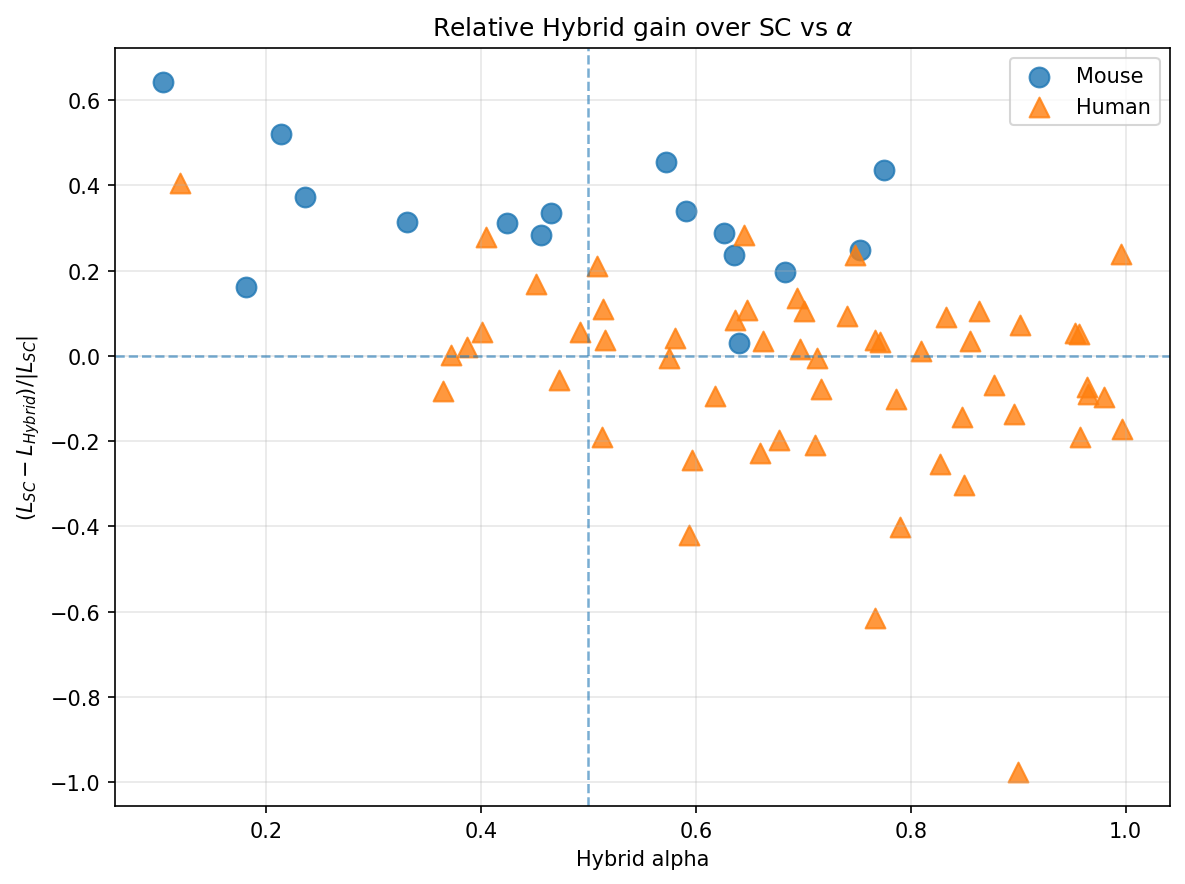

Saved: D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\Relative_gain_over_SC_vs_alpha.png


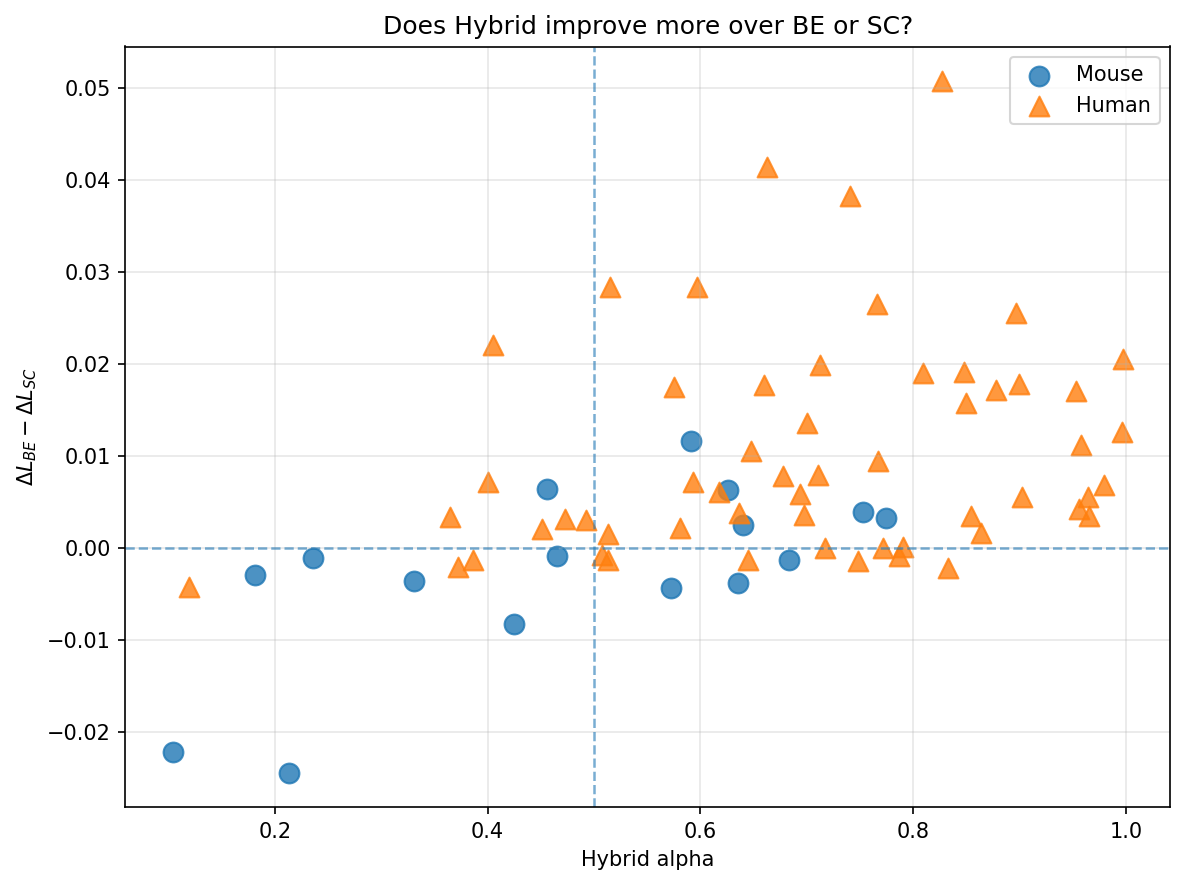

Saved: D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\Gain_difference_BE_minus_SC_vs_alpha.png


,species,x,y,spearman_rho,p_value,n
0,Mouse,Hybrid_alpha,DeltaL_BE,0.497059,0.050134,16
1,Mouse,Hybrid_alpha,DeltaL_SC,-0.535294,0.032616,16
2,Mouse,Hybrid_alpha,Relative_gain_over_BE,0.605882,0.012860,16
3,Mouse,Hybrid_alpha,Relative_gain_over_SC,-0.379412,0.147227,16
4,Mouse,Hybrid_alpha,Gain_difference_BE_minus_SC,0.541176,0.030400,16
5,Human,Hybrid_alpha,DeltaL_BE,0.222010,0.100075,56
6,Human,Hybrid_alpha,DeltaL_SC,-0.299863,0.024749,56
7,Human,Hybrid_alpha,Relative_gain_over_BE,0.201846,0.135749,56
8,Human,Hybrid_alpha,Relative_gain_over_SC,-0.260629,0.052373,56
9,Human,Hybrid_alpha,Gain_difference_BE_minus_SC,0.281750,0.035405,56


BE_train_error                     SC_train_error                      \
                  mean       std    median           mean       std    median   
species                                                                         
Human         0.025803  0.017921  0.023252       0.015472  0.011663  0.011612   
Mouse         0.011688  0.005322  0.010590       0.014145  0.009720  0.011804   

        Hybrid_train_error                     DeltaL_BE  ...  \
                      mean       std    median      mean  ...   
species                                                   ...   
Human             0.015984  0.012559  0.012267  0.009818  ...   
Mouse             0.008709  0.004471  0.008201  0.002979  ...   

        Relative_gain_over_BE Relative_gain_over_SC                      \
                       median                  mean       std    median   
species                                                                   
Human                0.337343             -0.039465  0.223984  0.013719   
Mouse                0.186503              0.323593  0.145770  0.312470   

        Gain_difference_BE_minus_SC                     Hybrid_alpha  \
                               mean       std    median         mean   
species                                                                
Human                      0.010330  0.011854  0.006417     0.700634   
Mouse                     -0.002456  0.009560 -0.001227     0.480426   

                             
              std    median  
species                      
Human    0.196148  0.711545  
Mouse    0.213158  0.518514  

[2 rows x 27 columns]

Saved:
D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\alpha_vs_hybrid_gain_correlations.csv
D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\hybrid_gain_summary.csv
D:\sc_modelling-amir-2025\hybrid_gain_vs_alpha\hybrid_gain_full_data.csv


: 

In [ ]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# =====================================================
# Settings
# =====================================================
root_dir = r"D:\sc_modelling-amir-2025"

mouse_subjects = [
    "QP0100", "QP0101", "QP0103", "QP0121",
    "QP062", "QP063", "QP070", "QP071"
]

human_subjects = [
    '6363339', '6363334', '6363353', '6363338', '6363346', '6363343',
    '6363329', '6363354', '6363347', '6363328', '6363330', '6363341',
    '6363407', '6363430', '6363368', '6363349', '6363364', '6269773',
    '6269770', '6269757', '6269881', '6357507', '6357495', '6357501',
    '6357497', '6357556', '6357698', '6357829'
]

samplers = ["CMA-ES", "TPE"]

folders = {
    "BE": "Hybrid_BE_fit",
    "SC": "Hybrid_SC_fit",
    "Hybrid": "Hybrid_new3_fit",
}

save_dir = os.path.join(root_dir, "hybrid_gain_vs_alpha")
os.makedirs(save_dir, exist_ok=True)


# =====================================================
# Helpers
# =====================================================
def find_result_file(folder, species, subject, sampler):
    search_dir = os.path.join(
        root_dir,
        folder,
        species,
        "results",
        sampler,
        subject
    )

    patterns = [
        os.path.join(search_dir, f"*{subject}*{sampler}*.pkl"),
        os.path.join(search_dir, "*.pkl"),
    ]

    files = []
    for pattern in patterns:
        files.extend(glob.glob(pattern))

    files = sorted(set(files))

    if len(files) == 0:
        return None

    return files[0]


def extract_params(data):
    if not isinstance(data, dict):
        return None

    if "best_params" in data:
        return data["best_params"]

    if "best_params_per_fold" in data:
        fold_params = data["best_params_per_fold"]

        if isinstance(fold_params, list) and len(fold_params) > 0:
            keys = fold_params[0].keys()

            return {
                k: np.nanmean([
                    fp[k] for fp in fold_params
                    if isinstance(fp, dict) and k in fp
                ])
                for k in keys
            }

    return None


def extract_train_error(data):
    if not isinstance(data, dict):
        return np.nan

    # Full-data fit case
    if "best_error" in data:
        return data["best_error"]

    # CV case
    if "train_errors" in data:
        return np.nanmean(data["train_errors"])

    # Fallback
    if "mean_cv_error" in data:
        return data["mean_cv_error"]

    return np.nan


def load_result(folder, species, subject, sampler):
    path = find_result_file(folder, species, subject, sampler)

    if path is None:
        return None, np.nan, None

    with open(path, "rb") as f:
        data = pickle.load(f)

    params = extract_params(data)
    train_error = extract_train_error(data)

    return params, train_error, path


# =====================================================
# Build dataframe
# =====================================================
rows = []

for species, subjects in [
    ("Mouse", mouse_subjects),
    ("Human", human_subjects)
]:
    for subject in subjects:
        for sampler in samplers:

            be_params, be_train_error, be_path = load_result(
                folders["BE"], species, subject, sampler
            )

            sc_params, sc_train_error, sc_path = load_result(
                folders["SC"], species, subject, sampler
            )

            hybrid_params, hybrid_train_error, hybrid_path = load_result(
                folders["Hybrid"], species, subject, sampler
            )

            if be_params is None or sc_params is None or hybrid_params is None:
                print("Missing:", species, subject, sampler)
                continue

            rows.append({
                "species": species,
                "subject": subject,
                "sampler": sampler,

                "BE_train_error": be_train_error,
                "SC_train_error": sc_train_error,
                "Hybrid_train_error": hybrid_train_error,

                "BE_sigma_noise": be_params.get("sigma_noise", np.nan),
                "SC_sigma_noise": sc_params.get("sigma_noise", np.nan),
                "Hybrid_sigma_noise": hybrid_params.get("sigma_noise", np.nan),

                "BE_A_repulsion": be_params.get("A_repulsion", np.nan),
                "SC_A_repulsion": sc_params.get("A_repulsion", np.nan),
                "Hybrid_A_repulsion": hybrid_params.get("A_repulsion", np.nan),

                "Hybrid_alpha": hybrid_params.get("alpha", np.nan),

                "BE_file": be_path,
                "SC_file": sc_path,
                "Hybrid_file": hybrid_path,
            })

df = pd.DataFrame(rows)

print("Loaded rows:", len(df))
display(df.head())

if len(df) == 0:
    raise ValueError("No files were loaded. Check folder structure.")


# =====================================================
# Loss differences
# =====================================================
df["DeltaL_BE"] = df["BE_train_error"] - df["Hybrid_train_error"]
df["DeltaL_SC"] = df["SC_train_error"] - df["Hybrid_train_error"]

# Positive values mean Hybrid is better
df["Hybrid_gain_over_BE"] = df["DeltaL_BE"]
df["Hybrid_gain_over_SC"] = df["DeltaL_SC"]

# Relative gains
eps = 1e-12
df["Relative_gain_over_BE"] = df["DeltaL_BE"] / (np.abs(df["BE_train_error"]) + eps)
df["Relative_gain_over_SC"] = df["DeltaL_SC"] / (np.abs(df["SC_train_error"]) + eps)

# Difference: positive means Hybrid improves more over BE than over SC
df["Gain_difference_BE_minus_SC"] = df["DeltaL_BE"] - df["DeltaL_SC"]


# =====================================================
# Plot helper
# =====================================================
def plot_vs_alpha(y_col, ylabel, title, save_name):
    plt.figure(figsize=(8, 6), dpi=150)

    for species, marker in [
        ("Mouse", "o"),
        ("Human", "^")
    ]:
        sub = df[df["species"] == species]

        plt.scatter(
            sub["Hybrid_alpha"],
            sub[y_col],
            marker=marker,
            s=90,
            alpha=0.8,
            label=species
        )

    plt.axhline(0, linestyle="--", linewidth=1.2, alpha=0.6)
    plt.axvline(0.5, linestyle="--", linewidth=1.2, alpha=0.6)

    plt.xlabel("Hybrid alpha")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    path = os.path.join(save_dir, save_name)
    plt.savefig(path, dpi=300)
    plt.show()

    print("Saved:", path)


# =====================================================
# Main plots
# =====================================================
plot_vs_alpha(
    y_col="DeltaL_BE",
    ylabel=r"$\Delta L_{BE}=L_{BE}-L_{Hybrid}$",
    title=r"Hybrid gain over BE vs $\alpha$",
    save_name="DeltaL_BE_vs_alpha.png"
)

plot_vs_alpha(
    y_col="DeltaL_SC",
    ylabel=r"$\Delta L_{SC}=L_{SC}-L_{Hybrid}$",
    title=r"Hybrid gain over SC vs $\alpha$",
    save_name="DeltaL_SC_vs_alpha.png"
)

plot_vs_alpha(
    y_col="Relative_gain_over_BE",
    ylabel=r"$(L_{BE}-L_{Hybrid})/|L_{BE}|$",
    title=r"Relative Hybrid gain over BE vs $\alpha$",
    save_name="Relative_gain_over_BE_vs_alpha.png"
)

plot_vs_alpha(
    y_col="Relative_gain_over_SC",
    ylabel=r"$(L_{SC}-L_{Hybrid})/|L_{SC}|$",
    title=r"Relative Hybrid gain over SC vs $\alpha$",
    save_name="Relative_gain_over_SC_vs_alpha.png"
)

plot_vs_alpha(
    y_col="Gain_difference_BE_minus_SC",
    ylabel=r"$\Delta L_{BE}-\Delta L_{SC}$",
    title=r"Does Hybrid improve more over BE or SC?",
    save_name="Gain_difference_BE_minus_SC_vs_alpha.png"
)


# =====================================================
# Correlations
# =====================================================
corr_rows = []

corr_pairs = [
    ("Hybrid_alpha", "DeltaL_BE"),
    ("Hybrid_alpha", "DeltaL_SC"),
    ("Hybrid_alpha", "Relative_gain_over_BE"),
    ("Hybrid_alpha", "Relative_gain_over_SC"),
    ("Hybrid_alpha", "Gain_difference_BE_minus_SC"),
]

for species in df["species"].unique():
    sub = df[df["species"] == species]

    for x_col, y_col in corr_pairs:
        valid = sub[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()

        if len(valid) >= 3:
            rho, p = spearmanr(valid[x_col], valid[y_col])
        else:
            rho, p = np.nan, np.nan

        corr_rows.append({
            "species": species,
            "x": x_col,
            "y": y_col,
            "spearman_rho": rho,
            "p_value": p,
            "n": len(valid)
        })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

corr_path = os.path.join(save_dir, "alpha_vs_hybrid_gain_correlations.csv")
corr_df.to_csv(corr_path, index=False)


# =====================================================
# Summary tables
# =====================================================
summary_cols = [
    "BE_train_error",
    "SC_train_error",
    "Hybrid_train_error",
    "DeltaL_BE",
    "DeltaL_SC",
    "Relative_gain_over_BE",
    "Relative_gain_over_SC",
    "Gain_difference_BE_minus_SC",
    "Hybrid_alpha"
]

gain_summary = df.groupby("species")[summary_cols].agg(["mean", "std", "median"])
display(gain_summary)

gain_summary_path = os.path.join(save_dir, "hybrid_gain_summary.csv")
gain_summary.to_csv(gain_summary_path)

df_path = os.path.join(save_dir, "hybrid_gain_full_data.csv")
df.to_csv(df_path, index=False)

print("Saved:")
print(corr_path)
print(gain_summary_path)
print(df_path)